# Proyecto Final — Asistente Fiscal con Gemini, RAG, Tool, LangGraph y Memoria

## Objetivo

Construir, en **un único notebook reproducible**, un asistente fiscal experto para startups y pymes centrado en:

- Impuesto sobre Sociedades.
- Ley 27/2014 del Impuesto sobre Sociedades.
- Ley 28/2022 de empresas emergentes.
- Orden PCM/825/2023 sobre certificación de empresas emergentes.
- Deducciones por I+D+i de los artículos 35 y 39 de la LIS.
- Fuentes oficiales BOE y AEAT.

## Arquitectura final

```mermaid
flowchart TD
    A([START]) --> B[prepare_query]
    B --> C[scope_guardrail]
    C -->|fuera del corpus| D[out_of_scope_response]
    D --> Z([END])
    C -->|dentro del corpus| E[rag_router]
    E -->|no necesita nueva búsqueda| F[direct_response]
    F --> Z
    E -->|necesita RAG| G[retrieve_documents]
    G -->|invoca search_tax_corpus| H[answer_with_context]
    H --> Z
```

La recuperación documental usa embeddings locales y Chroma. Gemini se reserva para la generación final, reduciendo llamadas y consumo de tokens.

## 0. Dependencias

La siguiente celda permite instalar las dependencias en un entorno nuevo. Se deja desactivada para no modificar un entorno ya preparado. Después de instalar por primera vez puede ser necesario reiniciar el kernel.

In [15]:
INSTALL_DEPENDENCIES = False

REQUIRED_PACKAGES = [
    "requests",
    "beautifulsoup4",
    "pymupdf",
    "pandas",
    "tqdm",
    "python-dotenv",
    "typing-extensions",
    "langchain-core",
    "langchain-text-splitters",
    "langchain-chroma",
    "langchain-huggingface",
    "sentence-transformers",
    "chromadb",
    "langchain-google-genai",
    "langgraph",
]

if INSTALL_DEPENDENCIES:
    import subprocess
    import sys

    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-U", *REQUIRED_PACKAGES]
    )
    print("Dependencias instaladas. Reinicia el kernel antes de continuar.")
else:
    print("Instalación omitida. Se utilizará el entorno actual.")

Instalación omitida. Se utilizará el entorno actual.


## 1. Imports

In [16]:
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime, timezone
from importlib.metadata import PackageNotFoundError, version
from typing import Annotated, Any, Literal
from uuid import uuid4
import hashlib
import json
import os
import re
import shutil
import time
import unicodedata

import chromadb
import fitz  # PyMuPDF
import pandas as pd
import requests
from bs4 import BeautifulSoup
from dotenv import load_dotenv
from IPython.display import Image, display
from tqdm.auto import tqdm
from typing_extensions import NotRequired, TypedDict

from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

## 2. Configuración reproducible

In [17]:
def find_project_root(start: Path | None = None) -> Path:
    """Localiza una raíz que contenga data/ o notebooks/."""
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() or (candidate / "notebooks").exists():
            return candidate

    return current


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
EVAL_OUTPUT_DIR = PROCESSED_DIR / "evaluation"
VECTORSTORE_DIR = DATA_DIR / "vectorstore" / "chroma"

BOE_OUTPUT = PROCESSED_DIR / "boe_articles.jsonl"
AEAT_HTML_OUTPUT = PROCESSED_DIR / "aeat_html_documents.jsonl"
AEAT_PDF_OUTPUT = PROCESSED_DIR / "aeat_pdf_pages.jsonl"
EXTRACTED_DOCUMENTS_FILE = PROCESSED_DIR / "extracted_documents.jsonl"
CHUNKS_FILE = PROCESSED_DIR / "chunks_langchain.jsonl"
DOWNLOAD_MANIFEST_FILE = RAW_DIR / "download_manifest.json"

COLLECTION_NAME = "rag_fiscal_startups"
EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
CHAT_MODEL = "gemini-2.5-flash"

CHUNK_SIZE = 2_500
CHUNK_OVERLAP = 250
BOE_KEEP_COMPLETE_MAX_CHARS = 5_000
AEAT_HTML_KEEP_COMPLETE_MAX_CHARS = 8_000

RETRIEVAL_K = 5
PRIORITY_K_PER_SOURCE = 2
MAX_DOC_CHARS = 1_600
MAX_CONTEXT_CHARS = 6_000
MAX_AGENT_OUTPUT_TOKENS = 550

# Si está en True, rehace extracción, chunks y Chroma aunque ya existan.
BUILD_FROM_SCRATCH = True

# Etapas que no consumen Gemini.
RUN_RETRIEVAL_EVAL = True
RUN_TOOL_SMOKE_TEST = True
RUN_LOCAL_ROUTING_EVAL = True
RUN_NON_LLM_GRAPH_DEMOS = True

# Etapas que sí pueden consumir Gemini.
RUN_RAG_DEMO = True
RUN_RAG_EVAL = True
RUN_GRAPH_LLM_DEMOS = True
RUN_GRAPH_STREAM_DEMO = True
RUN_GRAPH_EVAL = True

for directory in [RAW_DIR, PROCESSED_DIR, EVAL_OUTPUT_DIR, VECTORSTORE_DIR.parent]:
    directory.mkdir(parents=True, exist_ok=True)

load_dotenv(PROJECT_ROOT / ".env", override=False)
GOOGLE_API_KEY_AVAILABLE = bool(os.getenv("GOOGLE_API_KEY"))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BUILD_FROM_SCRATCH:", BUILD_FROM_SCRATCH)
print("GOOGLE_API_KEY disponible:", GOOGLE_API_KEY_AVAILABLE)
print("RUN_RAG_DEMO:", RUN_RAG_DEMO)
print("RUN_GRAPH_LLM_DEMOS:", RUN_GRAPH_LLM_DEMOS)

PROJECT_ROOT: C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\GENAI_RAG
BUILD_FROM_SCRATCH: True
GOOGLE_API_KEY disponible: True
RUN_RAG_DEMO: True
RUN_GRAPH_LLM_DEMOS: True


## 3. Fuentes oficiales

El corpus se limita deliberadamente a BOE y AEAT. Las consultas vinculantes de la DGT quedan fuera del alcance de esta versión.

In [18]:
SOURCES: list[dict[str, Any]] = [
    {
        "id": "boe_lis_ley_27_2014",
        "enabled": True,
        "file_type": "html",
        "raw_subdir": "boe",
        "filename": "01_boe_lis_ley_27_2014.html",
        "title": "Ley 27/2014 del Impuesto sobre Sociedades",
        "source": "BOE",
        "url": "https://www.boe.es/buscar/act.php?id=BOE-A-2014-12328",
        "tax": "Impuesto sobre Sociedades",
        "document_kind": "law",
        "document_role": "norma_base",
        "chunk_strategy": "article",
    },
    {
        "id": "boe_startups_ley_28_2022",
        "enabled": True,
        "file_type": "html",
        "raw_subdir": "boe",
        "filename": "02_boe_startups_ley_28_2022.html",
        "title": "Ley 28/2022 de fomento del ecosistema de las empresas emergentes",
        "source": "BOE",
        "url": "https://www.boe.es/buscar/act.php?id=BOE-A-2022-21739",
        "tax": "Startups",
        "document_kind": "law",
        "document_role": "norma_startups",
        "chunk_strategy": "article",
    },
    {
        "id": "boe_orden_pcm_825_2023_certificacion_startups",
        "enabled": True,
        "file_type": "html",
        "raw_subdir": "boe",
        "filename": "03_boe_orden_pcm_825_2023_certificacion_startups.html",
        "title": "Orden PCM/825/2023 sobre certificación de empresas emergentes",
        "source": "BOE",
        "url": "https://www.boe.es/buscar/act.php?id=BOE-A-2023-16817",
        "tax": "Startups",
        "document_kind": "order",
        "document_role": "certificacion_empresa_emergente",
        "chunk_strategy": "article",
    },
    {
        "id": "aeat_manual_sociedades_2025_pdf",
        "enabled": True,
        "file_type": "pdf",
        "raw_subdir": "aeat",
        "filename": "04_aeat_manual_sociedades_2025.pdf",
        "title": "Manual práctico de Sociedades 2025 AEAT",
        "source": "AEAT",
        "url": "https://sede.agenciatributaria.gob.es/static_files/Sede/Biblioteca/Manual/Practicos/Sociedades/Manual_Sociedades_2025.pdf",
        "tax": "Impuesto sobre Sociedades",
        "document_kind": "manual",
        "document_role": "manual_practico",
        "chunk_strategy": "pdf_pages_then_chunks",
    },
    {
        "id": "aeat_id_2025_art_35_1_lis",
        "enabled": True,
        "file_type": "html",
        "raw_subdir": "aeat",
        "filename": "05_aeat_id_2025_art_35_1_lis.html",
        "title": "Actividades de investigación y desarrollo - art. 35.1 LIS",
        "source": "AEAT",
        "url": "https://sede.agenciatributaria.gob.es/Sede/ayuda/manuales-videos-folletos/manuales-practicos/manual-sociedades-2025/capitulo-06-liquidacion-is-determinacion-tributaria/cuota-liquida-casilla-00592/deducc-incentiv-determ-activ-sujetas-lis/deducc-incent-determinadas-actividades-periodo-impositivo/deducc-activ-investigac-desarr-innovac-35_2/actividades-investigacion-desarrollo-articulo-35_1-lis.html",
        "tax": "Impuesto sobre Sociedades",
        "document_kind": "aeat_html",
        "document_role": "deduccion_id",
        "chunk_strategy": "html_sections",
    },
    {
        "id": "aeat_it_2025_art_35_2_lis",
        "enabled": True,
        "file_type": "html",
        "raw_subdir": "aeat",
        "filename": "06_aeat_it_2025_art_35_2_lis.html",
        "title": "Actividades de innovación tecnológica - art. 35.2 LIS",
        "source": "AEAT",
        "url": "https://sede.agenciatributaria.gob.es/Sede/ayuda/manuales-videos-folletos/manuales-practicos/manual-sociedades-2025/capitulo-06-liquidacion-is-determinacion-tributaria/cuota-liquida-casilla-00592/deducc-incentiv-determ-activ-sujetas-lis/deducc-incent-determinadas-actividades-periodo-impositivo/deducc-activ-investigac-desarr-innovac-35_2/actividades-innovacion-tecnologica-articulo-35_2-lis.html",
        "tax": "Impuesto sobre Sociedades",
        "document_kind": "aeat_html",
        "document_role": "deduccion_it",
        "chunk_strategy": "html_sections",
    },
    {
        "id": "aeat_idi_2025_art_39_2_lis",
        "enabled": True,
        "file_type": "html",
        "raw_subdir": "aeat",
        "filename": "07_aeat_idi_2025_art_39_2_lis.html",
        "title": "Deducciones excluidas del límite I+D+i - art. 39.2 LIS",
        "source": "AEAT",
        "url": "https://sede.agenciatributaria.gob.es/Sede/ayuda/manuales-videos-folletos/manuales-practicos/manual-sociedades-2025/capitulo-06-liquidacion-is-determinacion-tributaria/cuota-liquida-casilla-00592/deducciones-excluidas-limite-idi-articulo-lis.html",
        "tax": "Impuesto sobre Sociedades",
        "document_kind": "aeat_html",
        "document_role": "monetizacion_deducciones_idi",
        "chunk_strategy": "html_sections",
    },
]

source_catalog_df = pd.DataFrame(SOURCES)[
    ["id", "source", "title", "file_type", "document_role", "url"]
]
display(source_catalog_df)

,id,source,title,file_type,document_role,url
0,boe_lis_ley_27_2014,BOE,Ley 27/2014 del Impuesto sobre Sociedades,html,norma_base,https://www.boe.es/buscar/act.php?id=BOE-A-201...
1,boe_startups_ley_28_2022,BOE,Ley 28/2022 de fomento del ecosistema de las e...,html,norma_startups,https://www.boe.es/buscar/act.php?id=BOE-A-202...
2,boe_orden_pcm_825_2023_certificacion_startups,BOE,Orden PCM/825/2023 sobre certificación de empr...,html,certificacion_empresa_emergente,https://www.boe.es/buscar/act.php?id=BOE-A-202...
3,aeat_manual_sociedades_2025_pdf,AEAT,Manual práctico de Sociedades 2025 AEAT,pdf,manual_practico,https://sede.agenciatributaria.gob.es/static_f...
4,aeat_id_2025_art_35_1_lis,AEAT,Actividades de investigación y desarrollo - ar...,html,deduccion_id,https://sede.agenciatributaria.gob.es/Sede/ayu...
5,aeat_it_2025_art_35_2_lis,AEAT,Actividades de innovación tecnológica - art. 3...,html,deduccion_it,https://sede.agenciatributaria.gob.es/Sede/ayu...
6,aeat_idi_2025_art_39_2_lis,AEAT,Deducciones excluidas del límite I+D+i - art. ...,html,monetizacion_deducciones_idi,https://sede.agenciatributaria.gob.es/Sede/ayu...


## 4. Descarga y verificación de fuentes

In [19]:
HTTP_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 Chrome/120 Safari/537.36"
    ),
    "Accept": "text/html,application/pdf,application/xhtml+xml,*/*;q=0.8",
    "Accept-Language": "es-ES,es;q=0.9,en;q=0.8",
}


def get_raw_path(source: dict[str, Any]) -> Path:
    return RAW_DIR / source["raw_subdir"] / source["filename"]


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_obj:
        for block in iter(lambda: file_obj.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def download_source(
    session: requests.Session,
    source: dict[str, Any],
    force: bool = False,
) -> dict[str, Any]:
    output_path = get_raw_path(source)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and not force:
        return {
            "id": source["id"],
            "status": "reused_existing",
            "path": str(output_path.relative_to(PROJECT_ROOT)),
            "url": source["url"],
            "bytes": output_path.stat().st_size,
            "sha256": file_sha256(output_path),
            "downloaded_at_utc": None,
        }

    response = session.get(source["url"], timeout=120)
    response.raise_for_status()

    if source["file_type"] == "pdf" and not response.content.startswith(b"%PDF"):
        raise ValueError(f"{source['id']} no parece un PDF válido.")

    output_path.write_bytes(response.content)

    return {
        "id": source["id"],
        "status": "downloaded",
        "path": str(output_path.relative_to(PROJECT_ROOT)),
        "url": source["url"],
        "title": source["title"],
        "source": source["source"],
        "file_type": source["file_type"],
        "bytes": output_path.stat().st_size,
        "sha256": file_sha256(output_path),
        "downloaded_at_utc": datetime.now(timezone.utc).isoformat(),
    }


def ensure_raw_sources(force: bool = False) -> pd.DataFrame:
    records = []

    with requests.Session() as session:
        session.headers.update(HTTP_HEADERS)

        for source in SOURCES:
            if not source.get("enabled", True):
                continue

            try:
                record = download_source(session, source, force=force)
            except Exception as exc:
                record = {
                    "id": source["id"],
                    "status": "error",
                    "url": source["url"],
                    "error": str(exc),
                }

            records.append(record)

            if record["status"] == "downloaded":
                time.sleep(0.5)

    manifest = {
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "total_records": len(records),
        "records": records,
    }
    DOWNLOAD_MANIFEST_FILE.write_text(
        json.dumps(manifest, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    return pd.DataFrame(records)

In [20]:
raw_missing = [
    source["id"]
    for source in SOURCES
    if source.get("enabled", True) and not get_raw_path(source).exists()
]

if BUILD_FROM_SCRATCH or raw_missing:
    print("Fuentes ausentes o reconstrucción solicitada:", raw_missing)
    download_status_df = ensure_raw_sources(force=False)
else:
    download_status_df = pd.DataFrame(
        [
            {
                "id": source["id"],
                "status": "reused_existing",
                "path": str(get_raw_path(source).relative_to(PROJECT_ROOT)),
                "bytes": get_raw_path(source).stat().st_size,
                "sha256": file_sha256(get_raw_path(source)),
            }
            for source in SOURCES
            if source.get("enabled", True)
        ]
    )

if (download_status_df["status"] == "error").any():
    display(download_status_df)
    raise RuntimeError("Alguna fuente no pudo descargarse o verificarse.")

display(download_status_df)

Fuentes ausentes o reconstrucción solicitada: []


,id,status,path,url,bytes,sha256,downloaded_at_utc
0,boe_lis_ley_27_2014,reused_existing,data\raw\boe\01_boe_lis_ley_27_2014.html,https://www.boe.es/buscar/act.php?id=BOE-A-201...,1470383,ba3c6ec157b7d340c1dbe99481ea34af53ad9d65343200...,None
1,boe_startups_ley_28_2022,reused_existing,data\raw\boe\02_boe_startups_ley_28_2022.html,https://www.boe.es/buscar/act.php?id=BOE-A-202...,250617,570eb09d4c2c4cb65999494dec58efda7302ac2dc92a8e...,None
2,boe_orden_pcm_825_2023_certificacion_startups,reused_existing,data\raw\boe\03_boe_orden_pcm_825_2023_certifi...,https://www.boe.es/buscar/act.php?id=BOE-A-202...,79264,30b96f746e2076252127bf2006b36e412107c145b77929...,None
3,aeat_manual_sociedades_2025_pdf,reused_existing,data\raw\aeat\04_aeat_manual_sociedades_2025.pdf,https://sede.agenciatributaria.gob.es/static_f...,5178589,6e837ca4af4a7b67fcb5f062cd239ce8ced48dbefc4da5...,None
4,aeat_id_2025_art_35_1_lis,reused_existing,data\raw\aeat\05_aeat_id_2025_art_35_1_lis.html,https://sede.agenciatributaria.gob.es/Sede/ayu...,15598,368bb4a9fa67e4153ef275fb092e29dc3de905313c66e6...,None
5,aeat_it_2025_art_35_2_lis,reused_existing,data\raw\aeat\06_aeat_it_2025_art_35_2_lis.html,https://sede.agenciatributaria.gob.es/Sede/ayu...,17602,d7554db7f1fd34e897e311bdc361e7aa771db556bd9c33...,None
6,aeat_idi_2025_art_39_2_lis,reused_existing,data\raw\aeat\07_aeat_idi_2025_art_39_2_lis.html,https://sede.agenciatributaria.gob.es/Sede/ayu...,13371,b2f8596ae0856d65815433652148baeb0f6f0cf55bdc82...,None


## 5. Extracción documental

Mejoras respecto a los artefactos originales del repositorio:

- El BOE se extrae mediante su estructura HTML (`div.bloque`)
- Solo se conservan los artículos del cuerpo principal de cada norma.
- Se distinguen artículos como `15 bis`, `30 bis` o `38 ter`.
- Se excluyen controles de navegación, formularios de redacciones y marcadores de interfaz.
- Las páginas AEAT se extraen desde su elemento `<main>`, reduciendo ruido de cabeceras y menús.

In [21]:
def clean_text(text: str) -> str:
    text = str(text).replace("\xa0", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n[ \t]+", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def clean_extracted_lines(text: str) -> str:
    lines = []

    for raw_line in str(text).splitlines():
        line = re.sub(r"\s+", " ", raw_line).strip()

        if not line:
            continue
        if re.fullmatch(r"\[Bloque\s+\d+:\s*#[^\]]+\]", line):
            continue
        if line in {"Subir", "Jurisprudencia"}:
            continue

        lines.append(line)

    return clean_text("\n".join(lines))


def normalize_text(text: Any) -> str:
    if text is None:
        return ""

    normalized = unicodedata.normalize("NFD", str(text).lower())
    normalized = "".join(
        character
        for character in normalized
        if unicodedata.category(character) != "Mn"
    )
    normalized = re.sub(r"\s+", " ", normalized)
    return normalized.strip()


def slugify(text: str) -> str:
    value = normalize_text(text)
    return re.sub(r"[^a-z0-9]+", "_", value).strip("_")


def parse_article_label(heading: str) -> str | None:
    match = re.match(
        r"Artículo\s+(\d+)(?:\s+(bis|ter|quater|quinquies|sexies|septies|octies|nonies|decies))?",
        heading,
        flags=re.IGNORECASE,
    )

    if not match:
        return None

    number = match.group(1)
    suffix = match.group(2)
    return number if not suffix else f"{number} {suffix.lower()}"


def write_jsonl(path: Path, records: list[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file_obj:
        for record in records:
            file_obj.write(json.dumps(record, ensure_ascii=False) + "\n")


def load_jsonl(path: Path) -> list[dict[str, Any]]:
    records = []
    with path.open("r", encoding="utf-8") as file_obj:
        for line in file_obj:
            if line.strip():
                records.append(json.loads(line))
    return records

In [22]:
def source_metadata(source: dict[str, Any]) -> dict[str, Any]:
    return {
        "source_id": source["id"],
        "title": source["title"],
        "source": source["source"],
        "url": source["url"],
        "tax": source.get("tax"),
        "document_kind": source.get("document_kind"),
        "document_role": source.get("document_role"),
        "chunk_strategy": source.get("chunk_strategy"),
        "local_path": str(get_raw_path(source).relative_to(PROJECT_ROOT)),
    }


def extract_boe_main_articles(
    source: dict[str, Any],
    html: bytes | str,
) -> list[dict[str, Any]]:
    """Extrae artículos del cuerpo principal de una norma BOE."""
    soup = BeautifulSoup(html, "html.parser")
    records = []

    for block in soup.select("div.bloque[id]"):
        block_id = str(block.get("id", ""))

        # Los artículos principales usan identificadores que comienzan por "a".
        # Se excluyen disposiciones finales que contienen artículos de otras leyes.
        if not re.match(r"^a", block_id, flags=re.IGNORECASE):
            continue

        heading_tag = block.find("h5", class_="articulo")
        if heading_tag is None:
            continue

        heading = " ".join(heading_tag.get_text(" ", strip=True).split())
        if not heading.lower().startswith("artículo "):
            continue

        article = parse_article_label(heading)
        if not article:
            continue

        block_copy = BeautifulSoup(str(block), "html.parser")
        for selector in [
            "script",
            "style",
            ".linkSubir",
            ".nota_pie",
            ".nota_pie_2",
            "form.formBOE",
            "p.bloque",
        ]:
            for tag in block_copy.select(selector):
                tag.decompose()

        text = clean_extracted_lines(block_copy.get_text("\n"))
        if len(text) < 80:
            continue

        record_id = f"{source['id']}_art_{slugify(article)}"
        metadata = source_metadata(source)
        metadata.update(
            {
                "document_type": "boe_article",
                "article": article,
                "heading": heading,
                "boe_block_id": block_id,
            }
        )

        records.append({"id": record_id, "text": text, "metadata": metadata})

    return records


def extract_aeat_html(
    source: dict[str, Any],
    html: bytes | str,
) -> list[dict[str, Any]]:
    soup = BeautifulSoup(html, "html.parser")
    main = soup.select_one("main#acc-main") or soup.find("main") or soup.body

    if main is None:
        return []

    main_copy = BeautifulSoup(str(main), "html.parser")
    for selector in [
        "script",
        "style",
        "noscript",
        "svg",
        "button",
        "nav",
        "form",
        ".modal",
        ".offcanvas",
    ]:
        for tag in main_copy.select(selector):
            tag.decompose()

    text = clean_extracted_lines(main_copy.get_text("\n"))

    # El modal de generación de PDF no aporta contenido fiscal.
    pdf_modal_position = text.find("Generar PDF")
    if pdf_modal_position >= 0:
        text = text[:pdf_modal_position].rstrip()

    if len(text) < 100:
        return []

    metadata = source_metadata(source)
    metadata["document_type"] = "aeat_html"

    return [{"id": source["id"], "text": text, "metadata": metadata}]


def extract_pdf_pages(
    source: dict[str, Any],
    pdf_path: Path,
) -> list[dict[str, Any]]:
    pdf = fitz.open(pdf_path)
    records = []

    try:
        for page_number, page in enumerate(pdf, start=1):
            text = clean_text(page.get_text("text"))
            if len(text) < 100:
                continue

            metadata = source_metadata(source)
            metadata.update(
                {
                    "document_type": "pdf_page",
                    "page": page_number,
                }
            )

            records.append(
                {
                    "id": f"{source['id']}_page_{page_number}",
                    "text": text,
                    "metadata": metadata,
                }
            )
    finally:
        pdf.close()

    return records

In [23]:
def process_source(source: dict[str, Any]) -> list[dict[str, Any]]:
    raw_path = get_raw_path(source)

    if not source.get("enabled", True):
        return []
    if not raw_path.exists():
        raise FileNotFoundError(raw_path)

    if source["file_type"] == "html":
        html = raw_path.read_bytes()
        if source["source"] == "BOE":
            return extract_boe_main_articles(source, html)
        return extract_aeat_html(source, html)

    if source["file_type"] == "pdf":
        return extract_pdf_pages(source, raw_path)

    raise ValueError(f"Tipo no soportado: {source['file_type']}")


def build_extracted_corpus() -> list[dict[str, Any]]:
    boe_records: list[dict[str, Any]] = []
    aeat_html_records: list[dict[str, Any]] = []
    aeat_pdf_records: list[dict[str, Any]] = []

    for source in SOURCES:
        records = process_source(source)
        print(f"{source['id']}: {len(records)} registros")

        if source["source"] == "BOE":
            boe_records.extend(records)
        elif source["file_type"] == "html":
            aeat_html_records.extend(records)
        else:
            aeat_pdf_records.extend(records)

    all_records = [*boe_records, *aeat_html_records, *aeat_pdf_records]

    record_ids = [record["id"] for record in all_records]
    duplicated_ids = [item for item, count in Counter(record_ids).items() if count > 1]
    if duplicated_ids:
        raise ValueError(f"IDs duplicados tras la extracción: {duplicated_ids[:20]}")

    write_jsonl(BOE_OUTPUT, boe_records)
    write_jsonl(AEAT_HTML_OUTPUT, aeat_html_records)
    write_jsonl(AEAT_PDF_OUTPUT, aeat_pdf_records)
    write_jsonl(EXTRACTED_DOCUMENTS_FILE, all_records)

    return all_records

In [24]:
extraction_files = [
    BOE_OUTPUT,
    AEAT_HTML_OUTPUT,
    AEAT_PDF_OUTPUT,
    EXTRACTED_DOCUMENTS_FILE,
]

need_extraction = BUILD_FROM_SCRATCH or not all(path.exists() for path in extraction_files)

if need_extraction:
    extracted_records = build_extracted_corpus()
    extraction_status = "rebuilt"
else:
    extracted_records = load_jsonl(EXTRACTED_DOCUMENTS_FILE)
    extraction_status = "reused_existing"

extracted_ids = [record["id"] for record in extracted_records]
extracted_duplicate_ids = {
    item_id: count
    for item_id, count in Counter(extracted_ids).items()
    if count > 1
}

extraction_audit_df = pd.DataFrame(
    [
        {
            "source": record["metadata"].get("source"),
            "document_type": record["metadata"].get("document_type"),
            "chars": len(record["text"]),
        }
        for record in extracted_records
    ]
)

print("Estado:", extraction_status)
print("Registros extraídos:", len(extracted_records))
print("IDs duplicados:", len(extracted_duplicate_ids))

display(
    extraction_audit_df.groupby(["source", "document_type"])
    .agg(records=("chars", "size"), avg_chars=("chars", "mean"), max_chars=("chars", "max"))
    .reset_index()
)

if extracted_duplicate_ids:
    print(
        "AVISO: los artefactos reutilizados contienen IDs duplicados. "
        "Activa BUILD_FROM_SCRATCH=True para regenerarlos con el extractor corregido."
    )

boe_lis_ley_27_2014: 136 registros
boe_startups_ley_28_2022: 26 registros
boe_orden_pcm_825_2023_certificacion_startups: 17 registros
aeat_manual_sociedades_2025_pdf: 868 registros
aeat_id_2025_art_35_1_lis: 1 registros
aeat_it_2025_art_35_2_lis: 1 registros
aeat_idi_2025_art_39_2_lis: 1 registros
Estado: rebuilt
Registros extraídos: 1050
IDs duplicados: 0


,source,document_type,records,avg_chars,max_chars
0,AEAT,aeat_html,3,4573.000000,5884
1,AEAT,pdf_page,868,2501.217742,3976
2,BOE,boe_article,179,2815.748603,24314


## 6. Conversión a `Document` y chunking

In [25]:
def has_bad_encoding(text: str) -> bool:
    return any(marker in str(text) for marker in ["Ã", "Â", "�"])


def sanitize_metadata(metadata: dict[str, Any]) -> dict[str, Any]:
    clean_metadata: dict[str, Any] = {}

    for key, value in metadata.items():
        if value is None:
            continue
        if isinstance(value, (str, int, float, bool)):
            clean_metadata[key] = value
        else:
            clean_metadata[key] = str(value)

    return clean_metadata


def records_to_documents(records: list[dict[str, Any]]) -> list[Document]:
    documents = []

    for record in records:
        metadata = dict(record.get("metadata", {}))
        metadata["record_id"] = record["id"]
        metadata = sanitize_metadata(metadata)

        documents.append(
            Document(
                page_content=clean_text(record["text"]),
                metadata=metadata,
            )
        )

    return documents


text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],
)


def should_keep_complete(document: Document) -> bool:
    document_type = document.metadata.get("document_type")
    text_length = len(document.page_content)

    if document_type == "boe_article":
        return text_length <= BOE_KEEP_COMPLETE_MAX_CHARS

    if document_type == "aeat_html":
        return text_length <= AEAT_HTML_KEEP_COMPLETE_MAX_CHARS

    return False


def split_single_document(document: Document) -> list[Document]:
    if should_keep_complete(document):
        chunks = [
            Document(
                page_content=document.page_content,
                metadata=dict(document.metadata),
            )
        ]
    else:
        chunks = text_splitter.split_documents([document])

    for chunk_index, chunk in enumerate(chunks, start=1):
        chunk.metadata["chunk_index"] = chunk_index
        chunk.metadata["chunk_total"] = len(chunks)

    return chunks


def build_chunk_records(records: list[dict[str, Any]]) -> list[dict[str, Any]]:
    bad_encoding_records = [record["id"] for record in records if has_bad_encoding(record["text"])]
    if bad_encoding_records:
        raise ValueError(f"Posible mojibake en: {bad_encoding_records[:10]}")

    documents = records_to_documents(records)
    chunks: list[Document] = []

    for document in tqdm(documents, desc="Chunking"):
        chunks.extend(split_single_document(document))

    chunk_records = []
    for chunk in chunks:
        record_id = str(chunk.metadata["record_id"])
        chunk_index = int(chunk.metadata.get("chunk_index", 1))
        chunk_id = f"{record_id}_chunk_{chunk_index:03d}"

        metadata = dict(chunk.metadata)
        metadata["chunk_id"] = chunk_id
        metadata = sanitize_metadata(metadata)

        chunk_records.append(
            {"id": chunk_id, "text": chunk.page_content, "metadata": metadata}
        )

    chunk_ids = [record["id"] for record in chunk_records]
    duplicates = [item for item, count in Counter(chunk_ids).items() if count > 1]
    if duplicates:
        raise ValueError(f"Chunk IDs duplicados: {duplicates[:20]}")

    return chunk_records

In [26]:
need_chunking = BUILD_FROM_SCRATCH or need_extraction or not CHUNKS_FILE.exists()

if need_chunking:
    chunk_records = build_chunk_records(extracted_records)
    write_jsonl(CHUNKS_FILE, chunk_records)
    chunking_status = "rebuilt"
else:
    chunk_records = load_jsonl(CHUNKS_FILE)
    chunking_status = "reused_existing"

chunk_ids = [record["id"] for record in chunk_records]
if len(chunk_ids) != len(set(chunk_ids)):
    raise ValueError("chunks_langchain.jsonl contiene IDs duplicados.")

chunk_audit_df = pd.DataFrame(
    [
        {
            "source": record["metadata"].get("source"),
            "document_type": record["metadata"].get("document_type"),
            "chars": len(record["text"]),
        }
        for record in chunk_records
    ]
)

print("Estado:", chunking_status)
print("Chunks:", len(chunk_records))
print("IDs únicos:", len(set(chunk_ids)))

display(
    chunk_audit_df.groupby(["source", "document_type"])
    .agg(chunks=("chars", "size"), avg_chars=("chars", "mean"), max_chars=("chars", "max"))
    .reset_index()
)

Chunking: 100%|██████████| 1050/1050 [00:00<00:00, 22247.91it/s]


Estado: rebuilt
Chunks: 1688
IDs únicos: 1688


,source,document_type,chunks,avg_chars,max_chars
0,AEAT,aeat_html,3,4573.000000,5884
1,AEAT,pdf_page,1406,1620.832148,2500
2,BOE,boe_article,279,1838.301075,4841


## 7. Embeddings locales y Chroma

Se usa `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`. Gemini no participa en la indexación.

In [27]:
def chunk_records_to_documents(
    records: list[dict[str, Any]],
) -> tuple[list[Document], list[str]]:
    documents = []
    ids = []

    for record in records:
        documents.append(
            Document(
                page_content=record["text"],
                metadata=sanitize_metadata(
                    record["metadata"]
                ),
            )
        )

        ids.append(
            record["id"]
        )

    return documents, ids


def list_chroma_collection_names(
    client,
) -> list[str]:
    """
    Devuelve los nombres de las colecciones disponibles.

    Se utiliza el mismo PersistentClient durante toda
    la construcción para evitar bloqueos de SQLite
    en Windows.
    """
    collection_names = []

    for collection in client.list_collections():
        if isinstance(collection, str):
            collection_names.append(
                collection
            )

        else:
            collection_name = getattr(
                collection,
                "name",
                None,
            )

            if collection_name:
                collection_names.append(
                    collection_name
                )

    return collection_names


def build_vectorstore(
    records: list[dict[str, Any]],
    embeddings: HuggingFaceEmbeddings,
    client,
) -> Chroma:
    """
    Reconstruye únicamente la colección del proyecto.
    """
    existing_collections = (
        list_chroma_collection_names(
            client
        )
    )

    if COLLECTION_NAME in existing_collections:
        print(
            "Eliminando colección existente:",
            COLLECTION_NAME,
        )

        client.delete_collection(
            name=COLLECTION_NAME
        )

    store = Chroma(
        client=client,
        collection_name=COLLECTION_NAME,
        embedding_function=embeddings,
        create_collection_if_not_exists=True,
    )

    documents, ids = (
        chunk_records_to_documents(
            records
        )
    )

    batch_size = 100

    for start in tqdm(
        range(
            0,
            len(documents),
            batch_size,
        ),
        desc="Indexando Chroma",
    ):
        end = start + batch_size

        store.add_documents(
            documents=documents[start:end],
            ids=ids[start:end],
        )

    return store

In [28]:
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    encode_kwargs={
        "normalize_embeddings": True,
    },
)

VECTORSTORE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Se crea un único cliente persistente para toda
# la sección de construcción y carga.
chroma_client = chromadb.PersistentClient(
    path=str(VECTORSTORE_DIR)
)

available_collections = (
    list_chroma_collection_names(
        chroma_client
    )
)

existing_collection_count = None

if COLLECTION_NAME in available_collections:
    existing_collection_count = (
        chroma_client
        .get_collection(
            name=COLLECTION_NAME
        )
        .count()
    )

existing_collection_ok = (
    COLLECTION_NAME in available_collections
    and existing_collection_count
    == len(chunk_records)
)

need_vectorstore_rebuild = (
    BUILD_FROM_SCRATCH
    or need_chunking
    or not existing_collection_ok
)

print(
    "Colecciones disponibles:",
    available_collections,
)

print(
    "Vectores existentes:",
    existing_collection_count,
)

print(
    "Chunks actuales:",
    len(chunk_records),
)

print(
    "¿Es necesario reconstruir?:",
    need_vectorstore_rebuild,
)

if need_vectorstore_rebuild:
    vectorstore = build_vectorstore(
        records=chunk_records,
        embeddings=embeddings,
        client=chroma_client,
    )

    vectorstore_status = "rebuilt"

else:
    vectorstore = Chroma(
        client=chroma_client,
        collection_name=COLLECTION_NAME,
        embedding_function=embeddings,
        create_collection_if_not_exists=False,
    )

    vectorstore_status = "reused_existing"

vectorstore_count = (
    vectorstore
    ._collection
    .count()
)

if vectorstore_count != len(chunk_records):
    raise RuntimeError(
        "El número de vectores no coincide con "
        "el número de chunks.\n"
        f"Vectores: {vectorstore_count}\n"
        f"Chunks: {len(chunk_records)}"
    )

print()
print("Estado:", vectorstore_status)
print("Colección:", COLLECTION_NAME)
print("Vectores en Chroma:", vectorstore_count)
print("Chunks en JSONL:", len(chunk_records))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9623.85it/s]


Colecciones disponibles: ['rag_fiscal_startups']
Vectores existentes: 1709
Chunks actuales: 1688
¿Es necesario reconstruir?: True
Eliminando colección existente: rag_fiscal_startups


Indexando Chroma: 100%|██████████| 17/17 [00:40<00:00,  2.36s/it]


Estado: rebuilt
Colección: rag_fiscal_startups
Vectores en Chroma: 1688
Chunks en JSONL: 1688


## 8. Retrieval y contexto compacto

In [29]:
PRIORITY_SOURCE_RULES: list[tuple[tuple[str, ...], tuple[str, ...]]] = [
    (
        ("39.2", "abono", "sin limite", "excluidas del limite"),
        ("aeat_idi_2025_art_39_2_lis", "boe_lis_ley_27_2014"),
    ),
    (
        ("35.2", "innovacion tecnologica"),
        ("aeat_it_2025_art_35_2_lis", "boe_lis_ley_27_2014"),
    ),
    (
        ("35.1", "investigacion y desarrollo", "i+d"),
        ("aeat_id_2025_art_35_1_lis", "boe_lis_ley_27_2014"),
    ),
    (
        ("empresa emergente", "ley de startups", "certificacion", "enisa"),
        (
            "boe_startups_ley_28_2022",
            "boe_orden_pcm_825_2023_certificacion_startups",
        ),
    ),
]


def infer_priority_source_ids(query: str) -> list[str]:
    query_norm = normalize_text(query)
    selected: list[str] = []

    for markers, source_ids in PRIORITY_SOURCE_RULES:
        if any(normalize_text(marker) in query_norm for marker in markers):
            for source_id in source_ids:
                if source_id not in selected:
                    selected.append(source_id)

    return selected


def merge_retrieval_results(
    result_groups: list[list[tuple[Document, float]]],
    limit: int,
) -> list[tuple[Document, float]]:
    merged: list[tuple[Document, float]] = []
    seen_ids: set[str] = set()

    for group in result_groups:
        for document, score in group:
            unique_id = str(
                document.metadata.get("chunk_id")
                or document.metadata.get("record_id")
                or hashlib.sha1(document.page_content.encode("utf-8")).hexdigest()
            )

            if unique_id in seen_ids:
                continue

            seen_ids.add(unique_id)
            merged.append((document, score))

            if len(merged) >= limit:
                return merged

    return merged


def retrieve_tax_results(
    query: str,
    k: int = RETRIEVAL_K,
) -> list[tuple[Document, float]]:
    """Retrieval global con refuerzo de las fuentes especializadas."""
    clean_query = str(query).strip()
    if not clean_query:
        return []

    global_results = vectorstore.similarity_search_with_score(clean_query, k=k)
    priority_groups: list[list[tuple[Document, float]]] = []

    for source_id in infer_priority_source_ids(clean_query):
        filtered_results = vectorstore.similarity_search_with_score(
            clean_query,
            k=PRIORITY_K_PER_SOURCE,
            filter={"source_id": source_id},
        )
        priority_groups.append(filtered_results)

    return merge_retrieval_results([*priority_groups, global_results], limit=k)


def retrieval_results_to_df(
    results: list[tuple[Document, float]],
) -> pd.DataFrame:
    rows = []

    for rank, (document, score) in enumerate(results, start=1):
        metadata = document.metadata or {}
        rows.append(
            {
                "rank": rank,
                "distance_score": score,
                "source": metadata.get("source"),
                "title": metadata.get("title"),
                "source_id": metadata.get("source_id"),
                "document_type": metadata.get("document_type"),
                "article": metadata.get("article"),
                "page": metadata.get("page"),
                "chunk_id": metadata.get("chunk_id"),
                "url": metadata.get("url"),
                "preview": document.page_content[:400],
            }
        )

    return pd.DataFrame(rows)

In [30]:
def truncate_document_text(text: str, max_chars: int = MAX_DOC_CHARS) -> str:
    compact = re.sub(r"\s+", " ", str(text)).strip()

    if len(compact) <= max_chars:
        return compact

    truncated = compact[:max_chars]
    last_period = truncated.rfind(". ")
    if last_period >= int(max_chars * 0.60):
        truncated = truncated[: last_period + 1]

    return truncated.rstrip() + " […]"


def format_doc_for_context(
    document: Document,
    index: int,
) -> str:
    metadata = document.metadata or {}
    source = metadata.get("source", "Fuente no indicada")
    title = metadata.get("title", "Título no indicado")
    article = metadata.get("article")
    page = metadata.get("page")
    url = metadata.get("url", "")

    location_parts = []
    if article:
        location_parts.append(f"artículo {article}")
    if page:
        location_parts.append(f"página {page}")

    location = ", ".join(location_parts) if location_parts else "sin localización específica"
    content = truncate_document_text(document.page_content)

    return (
        f"[DOCUMENTO {index}]\n"
        f"Fuente: {source}\n"
        f"Título: {title}\n"
        f"Localización: {location}\n"
        f"URL: {url}\n\n"
        f"Contenido:\n{content}"
    )


def format_context_from_results(
    results: list[tuple[Document, float]],
) -> str:
    if not results:
        return "No se encontraron documentos relevantes en el corpus."

    blocks = []
    current_chars = 0

    for index, (document, _) in enumerate(results, start=1):
        block = format_doc_for_context(document, index)
        remaining = MAX_CONTEXT_CHARS - current_chars

        if remaining <= 300:
            break

        if len(block) > remaining:
            blocks.append(block[:remaining].rstrip() + "\n[CONTEXTO TRUNCADO]")
            break

        blocks.append(block)
        current_chars += len(block)

    return "\n\n".join(blocks)

### Prueba local de retrieval

In [31]:
LOCAL_RETRIEVAL_QUERY = (
    "¿Cómo funciona la aplicación sin límite o el abono de "
    "deducciones I+D+i del artículo 39.2 LIS?"
)

local_retrieval_results = retrieve_tax_results(LOCAL_RETRIEVAL_QUERY, k=RETRIEVAL_K)
display(
    retrieval_results_to_df(local_retrieval_results)[
        [
            "rank",
            "distance_score",
            "source",
            "title",
            "article",
            "page",
            "source_id",
        ]
    ]
)

,rank,distance_score,source,title,article,page,source_id
0,1,0.699954,AEAT,Deducciones excluidas del límite I+D+i - art. ...,NaN,NaN,aeat_idi_2025_art_39_2_lis
1,2,0.975116,BOE,Ley 27/2014 del Impuesto sobre Sociedades,39,NaN,boe_lis_ley_27_2014
2,3,1.013832,BOE,Ley 27/2014 del Impuesto sobre Sociedades,71,NaN,boe_lis_ley_27_2014
3,4,1.619032,AEAT,Actividades de investigación y desarrollo - ar...,NaN,NaN,aeat_id_2025_art_35_1_lis
4,5,0.615056,AEAT,Manual práctico de Sociedades 2025 AEAT,NaN,412.0,aeat_manual_sociedades_2025_pdf


## 9. Evaluación local del retrieval

In [32]:
RETRIEVAL_EVAL_CASES = [
    {
        "id": "startup_tipo_15",
        "question": "¿Puede una startup aplicar el tipo reducido del 15% en el Impuesto sobre Sociedades?",
        "expected_out_of_scope": False,
        "expected_sources_any": ["BOE", "AEAT"],
        "expected_articles_any": [],
        "expected_terms_any": ["15", "tipo reducido", "impuesto sobre sociedades"],
        "min_term_hits": 2,
    },
    {
        "id": "requisitos_empresa_emergente",
        "question": "¿Qué requisitos debe cumplir una empresa para ser considerada empresa emergente?",
        "expected_out_of_scope": False,
        "expected_sources_any": ["BOE"],
        "expected_articles_any": ["3", "4", "5", "6"],
        "expected_terms_any": ["empresa emergente", "ley 28/2022", "certificacion", "innovador"],
        "min_term_hits": 2,
    },
    {
        "id": "deduccion_id_art_35",
        "question": "¿Qué se considera investigación y desarrollo a efectos del artículo 35 LIS?",
        "expected_out_of_scope": False,
        "expected_sources_any": ["BOE", "AEAT"],
        "expected_articles_any": ["35"],
        "expected_terms_any": ["investigacion y desarrollo", "articulo 35", "deduccion", "i+d"],
        "min_term_hits": 2,
    },
    {
        "id": "innovacion_tecnologica_art_35_2",
        "question": "¿Qué se considera innovación tecnológica en el Impuesto sobre Sociedades?",
        "expected_out_of_scope": False,
        "expected_sources_any": ["BOE", "AEAT"],
        "expected_articles_any": ["35"],
        "expected_terms_any": ["innovacion tecnologica", "articulo 35", "deduccion"],
        "min_term_hits": 2,
    },
    {
        "id": "monetizacion_idi_art_39_2",
        "question": "¿Cómo funciona la aplicación sin límite o abono de deducciones I+D+i del artículo 39.2 LIS?",
        "expected_out_of_scope": False,
        "expected_sources_any": ["BOE", "AEAT"],
        "expected_articles_any": ["39"],
        "expected_terms_any": ["39.2", "abono", "insuficiencia de cuota", "i+d+i"],
        "min_term_hits": 2,
    },
    {
        "id": "fuera_corpus_iva",
        "question": "¿Cómo se liquida el IVA trimestral de una startup?",
        "expected_out_of_scope": True,
        "expected_sources_any": [],
        "expected_articles_any": [],
        "expected_terms_any": [],
        "min_term_hits": 0,
    },
    {
        "id": "fuera_corpus_laboral",
        "question": "¿Qué contrato laboral conviene hacer al primer empleado de una startup?",
        "expected_out_of_scope": True,
        "expected_sources_any": [],
        "expected_articles_any": [],
        "expected_terms_any": [],
        "min_term_hits": 0,
    },
]

In [33]:
def build_doc_blob(document: Document) -> str:
    metadata = document.metadata or {}
    parts = [
        document.page_content,
        metadata.get("source", ""),
        metadata.get("title", ""),
        metadata.get("article", ""),
        metadata.get("page", ""),
        metadata.get("source_id", ""),
    ]
    return normalize_text(" ".join(str(part) for part in parts))


def evaluate_retrieval_case(case: dict[str, Any]) -> dict[str, Any]:
    results = retrieve_tax_results(case["question"], k=RETRIEVAL_K)
    documents = [document for document, _ in results]
    scores = [score for _, score in results]
    full_blob = " ".join(build_doc_blob(document) for document in documents)

    expected_sources = case.get("expected_sources_any", [])
    expected_articles = case.get("expected_articles_any", [])
    expected_terms = case.get("expected_terms_any", [])

    source_hit = any(normalize_text(source) in full_blob for source in expected_sources)
    article_hit = (
        None
        if not expected_articles
        else any(normalize_text(article) in full_blob for article in expected_articles)
    )
    term_hits = [term for term in expected_terms if normalize_text(term) in full_blob]

    if case["expected_out_of_scope"]:
        retrieval_ok = None
    else:
        retrieval_ok = (
            source_hit
            and (article_hit is None or article_hit)
            and len(term_hits) >= case.get("min_term_hits", 2)
        )

    top_document = documents[0] if documents else None

    return {
        "id": case["id"],
        "question": case["question"],
        "expected_out_of_scope": case["expected_out_of_scope"],
        "source_hit_at_k": source_hit,
        "article_hit_at_k": article_hit,
        "term_hits_count": len(term_hits),
        "term_hits": term_hits,
        "retrieval_ok": retrieval_ok,
        "top_1_source": top_document.metadata.get("source") if top_document else None,
        "top_1_title": top_document.metadata.get("title") if top_document else None,
        "top_1_article": top_document.metadata.get("article") if top_document else None,
        "top_1_page": top_document.metadata.get("page") if top_document else None,
        "top_1_score": scores[0] if scores else None,
    }

In [34]:
if RUN_RETRIEVAL_EVAL:
    retrieval_eval_df = pd.DataFrame(
        [evaluate_retrieval_case(case) for case in RETRIEVAL_EVAL_CASES]
    )

    in_scope_retrieval = retrieval_eval_df[
        retrieval_eval_df["expected_out_of_scope"] == False
    ]
    retrieval_ok_rate = float(in_scope_retrieval["retrieval_ok"].mean())

    display(retrieval_eval_df)
    print("retrieval_ok_rate_in_scope:", retrieval_ok_rate)

    retrieval_eval_output = EVAL_OUTPUT_DIR / "retrieval_eval_single_notebook.csv"
    retrieval_eval_df.to_csv(retrieval_eval_output, index=False, encoding="utf-8-sig")
    print("Guardado en:", retrieval_eval_output)
else:
    print("Evaluación de retrieval desactivada.")

,id,question,expected_out_of_scope,source_hit_at_k,article_hit_at_k,term_hits_count,term_hits,retrieval_ok,top_1_source,top_1_title,top_1_article,top_1_page,top_1_score
0,startup_tipo_15,¿Puede una startup aplicar el tipo reducido de...,False,True,None,2,"[15, impuesto sobre sociedades]",True,AEAT,Manual práctico de Sociedades 2025 AEAT,NaN,685.0,0.511849
1,requisitos_empresa_emergente,¿Qué requisitos debe cumplir una empresa para ...,False,True,True,4,"[empresa emergente, ley 28/2022, certificacion...",True,BOE,Ley 28/2022 de fomento del ecosistema de las e...,6,NaN,0.628775
2,deduccion_id_art_35,¿Qué se considera investigación y desarrollo a...,False,True,True,3,"[investigacion y desarrollo, articulo 35, dedu...",True,AEAT,Actividades de investigación y desarrollo - ar...,NaN,NaN,0.832976
3,innovacion_tecnologica_art_35_2,¿Qué se considera innovación tecnológica en el...,False,True,True,3,"[innovacion tecnologica, articulo 35, deduccion]",True,AEAT,Actividades de innovación tecnológica - art. 3...,NaN,NaN,0.492494
4,monetizacion_idi_art_39_2,¿Cómo funciona la aplicación sin límite o abon...,False,True,True,4,"[39.2, abono, insuficiencia de cuota, i+d+i]",True,AEAT,Deducciones excluidas del límite I+D+i - art. ...,NaN,NaN,0.702807
5,fuera_corpus_iva,¿Cómo se liquida el IVA trimestral de una star...,True,False,None,0,[],None,AEAT,Manual práctico de Sociedades 2025 AEAT,NaN,823.0,0.989678
6,fuera_corpus_laboral,¿Qué contrato laboral conviene hacer al primer...,True,False,None,0,[],None,BOE,Ley 27/2014 del Impuesto sobre Sociedades,37,NaN,0.953979


retrieval_ok_rate_in_scope: 1.0
Guardado en: C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\GENAI_RAG\data\processed\evaluation\retrieval_eval_single_notebook.csv


## 10. Guardrails deterministas

In [35]:
STRONG_IN_SCOPE_KEYWORDS = (
    "impuesto sobre sociedades",
    "impuesto de sociedades",
    "ley 27/2014",
    "lis",
    "empresa emergente",
    "empresas emergentes",
    "ley de startups",
    "ley 28/2022",
    "orden pcm/825/2023",
    "enisa",
    "tipo reducido",
    "entidad de nueva creacion",
    "i+d",
    "i+d+i",
    "investigacion y desarrollo",
    "innovacion tecnologica",
    "articulo 35",
    "35.1",
    "35.2",
    "articulo 39",
    "39.2",
    "abono de deducciones",
    "deducciones excluidas del limite",
)

BROAD_IN_SCOPE_KEYWORDS = (
    "startup",
    "startups",
    "pyme",
    "pymes",
    "deduccion",
    "deducciones",
    "incentivo fiscal",
)

OUT_OF_SCOPE_KEYWORDS = (
    "iva",
    "irpf",
    "modelo 303",
    "modelo 130",
    "modelo 111",
    "retenciones",
    "nomina",
    "contrato laboral",
    "despido",
    "seguridad social",
    "autonomo",
    "cotizacion",
    "consulta vinculante",
    "direccion general de tributos",
    "dgt",
    "herencia",
    "sucesiones",
    "donaciones",
    "ibi",
    "itp",
    "aduanas",
)

FOLLOW_UP_MARKERS = (
    "y ",
    "entonces ",
    "en ese caso",
    "respecto a eso",
    "sobre eso",
    "esa empresa",
    "esa condicion",
    "ese requisito",
    "esa deduccion",
    "lo anterior",
    "durante cuanto",
    "que limite",
    "que porcentaje",
)


def contains_any_keyword(text: str, keywords: tuple[str, ...]) -> bool:
    normalized = normalize_text(text)
    return any(normalize_text(keyword) in normalized for keyword in keywords)


def build_out_of_scope_answer(question: str) -> str:
    return (
        "No puedo responder con base suficiente usando el corpus cargado.\n\n"
        f"Pregunta: {question}\n\n"
        "El corpus está limitado a Impuesto sobre Sociedades, empresas emergentes, "
        "Ley de Startups y deducciones por I+D+i de los artículos 35 y 39 LIS. "
        "Las consultas vinculantes de la DGT todavía no están integradas."
    )


def is_question_in_scope(
    question: str,
    conversation_context: str = "",
) -> bool:
    question_norm = normalize_text(question)
    context_norm = normalize_text(conversation_context)

    if not question_norm:
        return False

    # Las exclusiones explícitas tienen prioridad incluso si la pregunta menciona I+D+i.
    if contains_any_keyword(question_norm, OUT_OF_SCOPE_KEYWORDS):
        return False

    if contains_any_keyword(question_norm, STRONG_IN_SCOPE_KEYWORDS):
        return True

    if contains_any_keyword(question_norm, BROAD_IN_SCOPE_KEYWORDS):
        return True

    prior_context_is_fiscal = contains_any_keyword(
        context_norm,
        STRONG_IN_SCOPE_KEYWORDS,
    )
    looks_like_follow_up = any(
        marker in question_norm for marker in FOLLOW_UP_MARKERS
    )

    return prior_context_is_fiscal and looks_like_follow_up

### Router de peticiones que no necesitan una nueva búsqueda

In [36]:
NO_RAG_EXACT_REQUESTS = {
    "hola",
    "buenos dias",
    "buenas tardes",
    "buenas noches",
    "gracias",
    "muchas gracias",
    "de acuerdo",
    "entendido",
    "adios",
    "hasta luego",
    "que puedes hacer",
    "en que puedes ayudarme",
}

NO_RAG_TRANSFORMATION_MARKERS = (
    "resume la respuesta",
    "resume lo anterior",
    "resumelo",
    "hazlo mas breve",
    "hazla mas breve",
    "explicalo mas sencillo",
    "explicalo de forma sencilla",
    "reformula",
    "ponlo en una tabla",
    "muestralo en una tabla",
    "dame una version mas corta",
)


def is_no_rag_request(
    question: str,
    conversation_context: str = "",
) -> bool:
    question_norm = normalize_text(question)
    context_norm = normalize_text(conversation_context)

    if question_norm in NO_RAG_EXACT_REQUESTS:
        return True

    if question_norm.startswith("gracias") and len(question_norm.split()) <= 8:
        return True

    transformation = any(
        marker in question_norm for marker in NO_RAG_TRANSFORMATION_MARKERS
    )
    return transformation and bool(context_norm)

### Tests locales del guardrail y el router

In [37]:
ROUTING_TEST_CASES = [
    {
        "id": "scope_sociedades",
        "question": "¿Qué regula el artículo 35 de la LIS?",
        "context": "",
        "expected_in_scope": True,
        "expected_needs_rag": True,
    },
    {
        "id": "scope_follow_up",
        "question": "¿Y durante cuánto tiempo se mantiene esa condición?",
        "context": "Requisitos de una empresa emergente conforme a la Ley 28/2022.",
        "expected_in_scope": True,
        "expected_needs_rag": True,
    },
    {
        "id": "scope_greeting",
        "question": "Hola",
        "context": "",
        "expected_in_scope": True,
        "expected_needs_rag": False,
    },
    {
        "id": "scope_iva",
        "question": "¿Cómo presento el modelo 303 de IVA para una startup?",
        "context": "",
        "expected_in_scope": False,
        "expected_needs_rag": False,
    },
    {
        "id": "scope_dgt",
        "question": "Busca una consulta vinculante de la DGT sobre I+D+i.",
        "context": "",
        "expected_in_scope": False,
        "expected_needs_rag": False,
    },
]

routing_rows = []
for case in ROUTING_TEST_CASES:
    no_rag = is_no_rag_request(case["question"], case["context"])
    actual_in_scope = is_question_in_scope(case["question"], case["context"]) or no_rag
    actual_needs_rag = actual_in_scope and not no_rag

    routing_rows.append(
        {
            **case,
            "actual_in_scope": actual_in_scope,
            "actual_needs_rag": actual_needs_rag,
            "scope_ok": actual_in_scope == case["expected_in_scope"],
            "rag_router_ok": actual_needs_rag == case["expected_needs_rag"],
        }
    )

routing_eval_df = pd.DataFrame(routing_rows)
display(routing_eval_df)

if RUN_LOCAL_ROUTING_EVAL:
    assert routing_eval_df["scope_ok"].all()
    assert routing_eval_df["rag_router_ok"].all()
    print("Guardrail y router: tests locales superados.")

,id,question,context,expected_in_scope,expected_needs_rag,actual_in_scope,actual_needs_rag,scope_ok,rag_router_ok
0,scope_sociedades,¿Qué regula el artículo 35 de la LIS?,,True,True,True,True,True,True
1,scope_follow_up,¿Y durante cuánto tiempo se mantiene esa condi...,Requisitos de una empresa emergente conforme a...,True,True,True,True,True,True
2,scope_greeting,Hola,,True,False,True,False,True,True
3,scope_iva,¿Cómo presento el modelo 303 de IVA para una s...,,False,False,False,False,True,True
4,scope_dgt,Busca una consulta vinculante de la DGT sobre ...,,False,False,False,False,True,True


Guardrail y router: tests locales superados.


## 11. Gemini y RAG simple

In [38]:
_llm: ChatGoogleGenerativeAI | None = None


def get_llm() -> ChatGoogleGenerativeAI:
    global _llm

    if _llm is not None:
        return _llm

    if not GOOGLE_API_KEY_AVAILABLE:
        raise RuntimeError(
            "No se encontró GOOGLE_API_KEY. Añádela al archivo .env para ejecutar Gemini."
        )

    _llm = ChatGoogleGenerativeAI(
        model=CHAT_MODEL,
        temperature=0.2,
        max_tokens=MAX_AGENT_OUTPUT_TOKENS,
        thinking_budget=0,
        max_retries=1,
    )

    return _llm


print("Gemini configurado de forma perezosa. No se ha realizado ninguna llamada.")

Gemini configurado de forma perezosa. No se ha realizado ninguna llamada.


In [39]:
RAG_SYSTEM_PROMPT = """
Eres un asistente fiscal RAG especializado en Impuesto sobre Sociedades español,
empresas emergentes y deducciones por I+D+i.

Reglas obligatorias:
- Responde únicamente con el contexto recuperado.
- No inventes artículos, porcentajes, plazos, requisitos ni límites.
- Si el contexto es insuficiente, indícalo claramente.
- Cita BOE o AEAT, el título y el artículo o página disponible.
- Diferencia norma legal y explicación práctica de la AEAT.
- No reproduzcas íntegramente los documentos.
- Responde en español y de forma concisa.
- No sustituyes el asesoramiento fiscal profesional.

Estructura:
1. Respuesta.
2. Base normativa o fuente.
3. Aplicación práctica.
4. Límites o cautelas.
""".strip()


def message_to_text(message: Any) -> str:
    if message is None:
        return ""

    if isinstance(message, dict):
        content = message.get("content", "")
    else:
        content = getattr(message, "content", message)

    if isinstance(content, str):
        return content.strip()

    if isinstance(content, list):
        parts = []
        for block in content:
            if isinstance(block, str):
                parts.append(block)
            elif isinstance(block, dict):
                text = block.get("text") or block.get("content") or block.get("output")
                if text:
                    parts.append(str(text))
            else:
                text = getattr(block, "text", None)
                if text:
                    parts.append(str(text))
        return "\n".join(parts).strip()

    return str(content).strip()


def extract_final_answer(response: dict[str, Any]) -> str:
    messages = response.get("messages", [])

    for message in reversed(messages):
        message_type = getattr(message, "type", None)
        if message_type == "ai":
            text = message_to_text(message)
            if text:
                return text

        if isinstance(message, dict) and message.get("role") in {"assistant", "ai"}:
            text = message_to_text(message)
            if text:
                return text

    return ""

In [40]:
def rag_answer(question: str) -> dict[str, Any]:
    clean_question = str(question).strip()
    if not clean_question:
        raise ValueError("La pregunta no puede estar vacía.")

    if not is_question_in_scope(clean_question):
        return {
            "question": clean_question,
            "answer": build_out_of_scope_answer(clean_question),
            "generation_status": "guardrail",
            "retrieval_results": [],
            "context": "",
        }

    results = retrieve_tax_results(clean_question, k=RETRIEVAL_K)
    context = format_context_from_results(results)
    llm = get_llm()

    response = llm.invoke(
        [
            SystemMessage(content=RAG_SYSTEM_PROMPT),
            HumanMessage(
                content=(
                    f"PREGUNTA:\n{clean_question}\n\n"
                    f"CONTEXTO DOCUMENTAL:\n{context}"
                )
            ),
        ]
    )

    return {
        "question": clean_question,
        "answer": message_to_text(response),
        "generation_status": "success",
        "retrieval_results": results,
        "retrieval_df": retrieval_results_to_df(results),
        "context": context,
        "usage_metadata": getattr(response, "usage_metadata", None),
    }

In [41]:
if RUN_RAG_DEMO:
    rag_demo_result = rag_answer(
        "¿Puede una empresa emergente aplicar el tipo reducido del 15%?"
    )
    print(rag_demo_result["answer"])
    display(rag_demo_result["retrieval_df"])
else:
    print("Demo RAG no ejecutada porque RUN_RAG_DEMO=False.")

1. **Respuesta.**
Sí, una empresa emergente puede aplicar el tipo reducido del 15% en el Impuesto sobre Sociedades.

2. **Base normativa o fuente.**
* Ley 28/2022, de 21 de diciembre, de fomento del ecosistema de las empresas emergentes (BOE).
* Manual práctico de Sociedades 2025 (AEAT).

3. **Aplicación práctica.**
El Manual práctico de Sociedades 2025 de la AEAT indica que en la casilla [00558] del modelo 200 se consigna el tipo de gravamen reducido del 15% aplicable a las empresas emergentes (AEAT, Manual práctico de Sociedades 2025, página 378).

4. **Límites o cautelas.**
La empresa emergente dejará de acogerse a los beneficios previstos en la Ley 28/2022, incluyendo el tipo reducido, cuando ocurra alguno de los supuestos establecidos en el artículo 6 de dicha ley. Estos supuestos incluyen, entre otros, dejar de cumplir los requisitos de empresa emergente, superar los diez millones de euros de volumen de negocio anual, o que la empresa sea adquirida por otra que no sea emergente (

,rank,distance_score,source,title,source_id,document_type,article,page,chunk_id,url,preview
0,1,0.763489,BOE,Ley 28/2022 de fomento del ecosistema de las e...,boe_startups_ley_28_2022,boe_article,6,NaN,boe_startups_ley_28_2022_art_6_chunk_001,https://www.boe.es/buscar/act.php?id=BOE-A-202...,Artículo 6. Fin de aplicación de los beneficio...
1,2,0.802060,BOE,Ley 28/2022 de fomento del ecosistema de las e...,boe_startups_ley_28_2022,boe_article,22,NaN,boe_startups_ley_28_2022_art_22_chunk_001,https://www.boe.es/buscar/act.php?id=BOE-A-202...,Artículo 22. Reducción de garantías.\nCuando l...
2,3,0.920025,BOE,Orden PCM/825/2023 sobre certificación de empr...,boe_orden_pcm_825_2023_certificacion_startups,boe_article,5,NaN,boe_orden_pcm_825_2023_certificacion_startups_...,https://www.boe.es/buscar/act.php?id=BOE-A-202...,Artículo 5. Criterios de evaluación del caráct...
3,4,0.975358,BOE,Orden PCM/825/2023 sobre certificación de empr...,boe_orden_pcm_825_2023_certificacion_startups,boe_article,10,NaN,boe_orden_pcm_825_2023_certificacion_startups_...,https://www.boe.es/buscar/act.php?id=BOE-A-202...,Artículo 10. Fin de la aplicación de los benef...
4,5,0.637673,AEAT,Manual práctico de Sociedades 2025 AEAT,aeat_manual_sociedades_2025_pdf,pdf_page,NaN,378.0,aeat_manual_sociedades_2025_pdf_page_378_chunk...,https://sede.agenciatributaria.gob.es/static_f...,En la casilla [00558] está consignado el tipo ...


### Evaluación generativa del RAG

In [42]:
def classify_api_error(exc: Exception) -> str:
    error_text = normalize_text(str(exc))

    if any(
        marker in error_text
        for marker in [
            "429",
            "resource_exhausted",
            "quota",
            "rate limit",
            "too many requests",
            "503",
            "unavailable",
            "high demand",
        ]
    ):
        return "api_error"

    if any(marker in error_text for marker in ["api key", "unauthorized", "401"]):
        return "auth_error"

    return "runtime_error"


def answer_has_source_markers(answer: str) -> bool:
    answer_norm = normalize_text(answer)
    return any(
        marker in answer_norm
        for marker in ["boe", "aeat", "ley", "articulo", "pagina", "fuente"]
    )


def answer_says_insufficient(answer: str) -> bool:
    answer_norm = normalize_text(answer)
    return any(
        marker in answer_norm
        for marker in [
            "no puedo responder",
            "contexto insuficiente",
            "no contiene",
            "no hay base suficiente",
            "corpus cargado",
        ]
    )


def run_rag_evaluation(cases: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []

    for case in cases:
        try:
            result = rag_answer(case["question"])
            answer = result["answer"]
            expected_out = case["expected_out_of_scope"]

            if expected_out:
                answer_ok = answer_says_insufficient(answer)
            else:
                expected_terms = case.get("expected_terms_any", [])
                term_hits = [
                    term for term in expected_terms if normalize_text(term) in normalize_text(answer)
                ]
                answer_ok = answer_has_source_markers(answer) and bool(term_hits)

            rows.append(
                {
                    "id": case["id"],
                    "question": case["question"],
                    "expected_out_of_scope": expected_out,
                    "generation_status": result["generation_status"],
                    "answer_ok": answer_ok,
                    "answer_preview": answer[:800],
                    "error_type": None,
                    "error": None,
                }
            )

        except Exception as exc:
            rows.append(
                {
                    "id": case["id"],
                    "question": case["question"],
                    "expected_out_of_scope": case["expected_out_of_scope"],
                    "generation_status": classify_api_error(exc),
                    "answer_ok": None,
                    "answer_preview": "",
                    "error_type": type(exc).__name__,
                    "error": str(exc),
                }
            )

    return pd.DataFrame(rows)

In [43]:
if RUN_RAG_EVAL:
    rag_generation_eval_df = run_rag_evaluation(RETRIEVAL_EVAL_CASES)
    display(rag_generation_eval_df)

    rag_eval_output = EVAL_OUTPUT_DIR / "generation_eval_single_notebook.csv"
    rag_generation_eval_df.to_csv(rag_eval_output, index=False, encoding="utf-8-sig")
    print("Guardado en:", rag_eval_output)
else:
    print("Evaluación generativa no ejecutada porque RUN_RAG_EVAL=False.")

,id,question,expected_out_of_scope,generation_status,answer_ok,answer_preview,error_type,error
0,startup_tipo_15,¿Puede una startup aplicar el tipo reducido de...,False,success,True,1. **Respuesta:**\n El contexto proporcion...,None,None
1,requisitos_empresa_emergente,¿Qué requisitos debe cumplir una empresa para ...,False,success,True,1. **Respuesta.**\nPara ser considerada una em...,None,None
2,deduccion_id_art_35,¿Qué se considera investigación y desarrollo a...,False,success,True,1. **Respuesta.**\nSe considera investigación ...,None,None
3,innovacion_tecnologica_art_35_2,¿Qué se considera innovación tecnológica en el...,False,success,True,1. **Respuesta.**\nSe considera innovación tec...,None,None
4,monetizacion_idi_art_39_2,¿Cómo funciona la aplicación sin límite o abon...,False,success,True,1. **Respuesta.**\nLas entidades que tributen ...,None,None
5,fuera_corpus_iva,¿Cómo se liquida el IVA trimestral de una star...,True,guardrail,True,No puedo responder con base suficiente usando ...,None,None
6,fuera_corpus_laboral,¿Qué contrato laboral conviene hacer al primer...,True,guardrail,True,No puedo responder con base suficiente usando ...,None,None


Guardado en: C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\GENAI_RAG\data\processed\evaluation\generation_eval_single_notebook.csv


## 12. Tool RAG

In [44]:
@tool
def search_tax_corpus(query: str) -> str:
    """
    Busca información en el corpus fiscal oficial del proyecto.

    Ámbito:
    - Impuesto sobre Sociedades.
    - Empresas emergentes y Ley de Startups.
    - Deducciones por I+D+i.
    - Artículos 35 y 39 LIS.
    - Fuentes BOE y AEAT incorporadas al vectorstore.
    """
    clean_query = str(query).strip()
    if not clean_query:
        return "La consulta de búsqueda está vacía."

    results = retrieve_tax_results(clean_query, k=RETRIEVAL_K)
    return format_context_from_results(results)


print("Tool creada:", search_tax_corpus.name)

Tool creada: search_tax_corpus


In [45]:
if RUN_TOOL_SMOKE_TEST:
    tool_smoke_output = search_tax_corpus.invoke(
        {
            "query": (
                "¿Qué requisitos debe cumplir una empresa para ser "
                "considerada empresa emergente?"
            )
        }
    )
    print(tool_smoke_output[:2_500])
    print("\nLongitud total del contexto:", len(tool_smoke_output), "caracteres")
else:
    print("Prueba de tool desactivada.")

[DOCUMENTO 1]
Fuente: BOE
Título: Ley 28/2022 de fomento del ecosistema de las empresas emergentes
Localización: artículo 6
URL: https://www.boe.es/buscar/act.php?id=BOE-A-2022-21739

Contenido:
Artículo 6. Fin de aplicación de los beneficios y especialidades de esta ley. La empresa emergente y sus inversores no podrán o dejarán de acogerse a los beneficios previstos en esta ley cuando ocurra alguno de los siguientes supuestos: a) Deje de cumplir cualquiera de los requisitos previstos en el artículo 3 y, en particular, al término de los cinco o siete años desde la creación de la empresa emergente. b) Se extinga la empresa antes de ese término. c) Sea adquirida por otra empresa que no tenga la condición de empresa emergente. d) El volumen de negocio anual de la empresa supere el valor de diez millones de euros. e) Lleve a cabo una actividad que genere un daño significativo al medio ambiente conforme al Reglamento (UE) 2020/852 del Parlamento Europeo y del Consejo de 18 de junio de 2020 

## 13. Grafo explícito con LangGraph

La tool se conserva, pero la decisión de utilizarla es determinista. El modelo no necesita una llamada previa para decidir si debe buscar.

In [46]:
class FiscalGraphState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

    user_query: NotRequired[str]
    conversation_context: NotRequired[str]
    previous_human_query: NotRequired[str]

    in_scope: NotRequired[bool]
    needs_rag: NotRequired[bool]

    retrieval_query: NotRequired[str]
    retrieved_context: NotRequired[str]
    retrieval_status: NotRequired[str]
    tool_used: NotRequired[bool]
    graph_path: NotRequired[str]

In [47]:
def get_last_human_message_text(state: dict[str, Any]) -> str:
    messages = state.get("messages", [])

    for message in reversed(messages):
        if isinstance(message, dict) and message.get("role") in {"user", "human"}:
            return message_to_text(message)
        if getattr(message, "type", None) == "human":
            return message_to_text(message)

    return ""


def messages_before_current_human(state: dict[str, Any]) -> list[Any]:
    messages = list(state.get("messages", []))

    for index in range(len(messages) - 1, -1, -1):
        message = messages[index]
        is_human = (
            getattr(message, "type", None) == "human"
            or (
                isinstance(message, dict)
                and message.get("role") in {"user", "human"}
            )
        )
        if is_human:
            return messages[:index]

    return messages


def get_recent_conversation_text(
    state: dict[str, Any],
    n_messages: int = 6,
) -> str:
    prior_messages = messages_before_current_human(state)[-n_messages:]
    return "\n".join(
        message_to_text(message)
        for message in prior_messages
        if message_to_text(message)
    )


def get_previous_human_query(state: dict[str, Any]) -> str:
    prior_messages = messages_before_current_human(state)

    for message in reversed(prior_messages):
        if getattr(message, "type", None) == "human":
            return message_to_text(message)
        if isinstance(message, dict) and message.get("role") in {"user", "human"}:
            return message_to_text(message)

    return ""


def get_last_ai_message_text(state: dict[str, Any]) -> str:
    prior_messages = messages_before_current_human(state)

    for message in reversed(prior_messages):
        if getattr(message, "type", None) == "ai":
            return message_to_text(message)
        if isinstance(message, dict) and message.get("role") in {"assistant", "ai"}:
            return message_to_text(message)

    return ""

### Nodo 1 — `prepare_query`

In [48]:
def prepare_query_node(state: FiscalGraphState) -> dict[str, Any]:
    user_query = get_last_human_message_text(state)
    if not user_query:
        raise ValueError("No se encontró una pregunta humana en el estado.")

    return {
        "user_query": user_query,
        "conversation_context": get_recent_conversation_text(state, n_messages=6),
        "previous_human_query": get_previous_human_query(state),
        "in_scope": False,
        "needs_rag": False,
        "retrieval_query": "",
        "retrieved_context": "",
        "retrieval_status": "not_run",
        "tool_used": False,
        "graph_path": "prepared",
    }

### Nodo 2 — `scope_guardrail` y router

In [49]:
def scope_guardrail_node(state: FiscalGraphState) -> dict[str, Any]:
    question = state.get("user_query", "")
    context = state.get("conversation_context", "")

    no_rag_request = is_no_rag_request(question, context)
    fiscal_question = is_question_in_scope(question, context)

    return {
        "in_scope": fiscal_question or no_rag_request,
        "graph_path": "scope_checked",
    }


def route_after_scope_guardrail(
    state: FiscalGraphState,
) -> Literal["rag_router", "out_of_scope_response"]:
    return "rag_router" if state.get("in_scope", False) else "out_of_scope_response"

### Nodo alternativo — `out_of_scope_response`

In [50]:
def out_of_scope_response_node(state: FiscalGraphState) -> dict[str, Any]:
    answer = build_out_of_scope_answer(state.get("user_query", ""))
    return {
        "messages": [AIMessage(content=answer)],
        "needs_rag": False,
        "tool_used": False,
        "graph_path": "out_of_scope",
    }

### Nodo 3 — `rag_router` y router

In [51]:
def rag_router_node(state: FiscalGraphState) -> dict[str, Any]:
    needs_rag = not is_no_rag_request(
        state.get("user_query", ""),
        state.get("conversation_context", ""),
    )

    return {
        "needs_rag": needs_rag,
        "graph_path": "rag_required" if needs_rag else "direct_response",
    }


def route_after_rag_router(
    state: FiscalGraphState,
) -> Literal["retrieve_documents", "direct_response"]:
    return "retrieve_documents" if state.get("needs_rag", True) else "direct_response"

### Nodo alternativo — `direct_response`

In [52]:
DIRECT_RESPONSE_SYSTEM_PROMPT = """
Eres un asistente fiscal conversacional.
No añadas información fiscal nueva. Limítate a resumir, reformular o cambiar
el formato de la respuesta anterior. Responde en español y de forma concisa.
""".strip()


def build_fixed_direct_answer(question: str) -> str | None:
    question_norm = normalize_text(question)

    if question_norm in {"hola", "buenos dias", "buenas tardes", "buenas noches"}:
        return (
            "Hola. Puedo ayudarte con Impuesto sobre Sociedades, empresas "
            "emergentes y deducciones por I+D+i."
        )
    if question_norm.startswith("gracias"):
        return "De nada."
    if question_norm in {"adios", "hasta luego"}:
        return "Hasta luego."
    if question_norm in {"que puedes hacer", "en que puedes ayudarme"}:
        return (
            "Puedo consultar fuentes BOE y AEAT sobre Impuesto sobre Sociedades, "
            "empresas emergentes y deducciones por I+D+i."
        )

    return None


def direct_response_node(state: FiscalGraphState) -> dict[str, Any]:
    question = state.get("user_query", "")
    fixed_answer = build_fixed_direct_answer(question)

    if fixed_answer is not None:
        return {
            "messages": [AIMessage(content=fixed_answer)],
            "tool_used": False,
            "graph_path": "direct_response",
        }

    previous_answer = get_last_ai_message_text(state)
    if not previous_answer:
        return {
            "messages": [AIMessage(content="No existe una respuesta anterior que reformular.")],
            "tool_used": False,
            "graph_path": "direct_response",
        }

    response = get_llm().invoke(
        [
            SystemMessage(content=DIRECT_RESPONSE_SYSTEM_PROMPT),
            HumanMessage(
                content=(
                    f"RESPUESTA ANTERIOR:\n{previous_answer[-3_500:]}\n\n"
                    f"PETICIÓN ACTUAL:\n{question}"
                )
            ),
        ]
    )

    return {
        "messages": [response],
        "tool_used": False,
        "graph_path": "direct_response",
    }

### Nodo 4 — `retrieve_documents`, que invoca la tool

In [53]:
DOMAIN_QUERY_HINTS = [
    (
        ("39.2", "abono", "sin limite"),
        "Deducciones I+D+i excluidas del límite, artículo 39.2 LIS, descuento del 20 %, abono e insuficiencia de cuota.",
    ),
    (
        ("35.2", "innovacion tecnologica"),
        "Concepto, base y porcentaje de innovación tecnológica del artículo 35.2 LIS.",
    ),
    (
        ("35.1", "investigacion y desarrollo", "i+d"),
        "Concepto, base y porcentajes de investigación y desarrollo del artículo 35.1 LIS.",
    ),
    (
        ("empresa emergente", "ley de startups", "enisa"),
        "Requisitos, certificación y pérdida de la condición de empresa emergente conforme a la Ley 28/2022 y la Orden PCM/825/2023.",
    ),
]


def build_retrieval_query(
    user_query: str,
    previous_human_query: str = "",
) -> str:
    query_norm = normalize_text(user_query)
    hints = [
        hint
        for markers, hint in DOMAIN_QUERY_HINTS
        if any(normalize_text(marker) in query_norm for marker in markers)
    ]

    parts = [f"Pregunta actual: {user_query}"]
    if previous_human_query:
        parts.append(f"Pregunta fiscal anterior del hilo: {previous_human_query}")
    if hints:
        parts.append("Términos de recuperación: " + " ".join(hints))

    return "\n".join(parts)


def retrieve_documents_node(state: FiscalGraphState) -> dict[str, Any]:
    retrieval_query = build_retrieval_query(
        user_query=state.get("user_query", ""),
        previous_human_query=state.get("previous_human_query", ""),
    )

    retrieved_context = search_tax_corpus.invoke({"query": retrieval_query})

    return {
        "retrieval_query": retrieval_query,
        "retrieved_context": retrieved_context,
        "retrieval_status": "success",
        "tool_used": True,
        "graph_path": "rag",
    }

### Nodo 5 — `answer_with_context`

In [54]:
def answer_with_context_node(state: FiscalGraphState) -> dict[str, Any]:
    retrieved_context = state.get("retrieved_context", "")

    if not retrieved_context:
        return {
            "messages": [
                AIMessage(
                    content="No se recuperó contexto documental suficiente para responder."
                )
            ],
            "graph_path": "rag_without_context",
        }

    conversation_context = state.get("conversation_context", "")[-1_800:]

    response = get_llm().invoke(
        [
            SystemMessage(content=RAG_SYSTEM_PROMPT),
            HumanMessage(
                content=(
                    f"CONTEXTO CONVERSACIONAL PREVIO:\n{conversation_context or 'Sin contexto previo.'}\n\n"
                    f"PREGUNTA ACTUAL:\n{state.get('user_query', '')}\n\n"
                    f"CONTEXTO DOCUMENTAL RECUPERADO:\n{retrieved_context}"
                )
            ),
        ]
    )

    return {
        "messages": [response],
        "graph_path": "rag",
    }

### Construcción y compilación del grafo

In [55]:
graph_builder = StateGraph(FiscalGraphState)

graph_builder.add_node("prepare_query", prepare_query_node)
graph_builder.add_node("scope_guardrail", scope_guardrail_node)
graph_builder.add_node("out_of_scope_response", out_of_scope_response_node)
graph_builder.add_node("rag_router", rag_router_node)
graph_builder.add_node("direct_response", direct_response_node)
graph_builder.add_node("retrieve_documents", retrieve_documents_node)
graph_builder.add_node("answer_with_context", answer_with_context_node)

graph_builder.add_edge(START, "prepare_query")
graph_builder.add_edge("prepare_query", "scope_guardrail")

graph_builder.add_conditional_edges(
    "scope_guardrail",
    route_after_scope_guardrail,
    {
        "rag_router": "rag_router",
        "out_of_scope_response": "out_of_scope_response",
    },
)

graph_builder.add_edge("out_of_scope_response", END)

graph_builder.add_conditional_edges(
    "rag_router",
    route_after_rag_router,
    {
        "retrieve_documents": "retrieve_documents",
        "direct_response": "direct_response",
    },
)

graph_builder.add_edge("direct_response", END)
graph_builder.add_edge("retrieve_documents", "answer_with_context")
graph_builder.add_edge("answer_with_context", END)

checkpointer = InMemorySaver()
fiscal_graph = graph_builder.compile(checkpointer=checkpointer)

print("Grafo fiscal compilado con InMemorySaver.")

Grafo fiscal compilado con InMemorySaver.


### Visualización del grafo

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	prepare_query(prepare_query)
	scope_guardrail(scope_guardrail)
	out_of_scope_response(out_of_scope_response)
	rag_router(rag_router)
	direct_response(direct_response)
	retrieve_documents(retrieve_documents)
	answer_with_context(answer_with_context)
	__end__([<p>__end__</p>]):::last
	__start__ --> prepare_query;
	prepare_query --> scope_guardrail;
	rag_router -.-> direct_response;
	rag_router -.-> retrieve_documents;
	retrieve_documents --> answer_with_context;
	scope_guardrail -.-> out_of_scope_response;
	scope_guardrail -.-> rag_router;
	answer_with_context --> __end__;
	direct_response --> __end__;
	out_of_scope_response --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



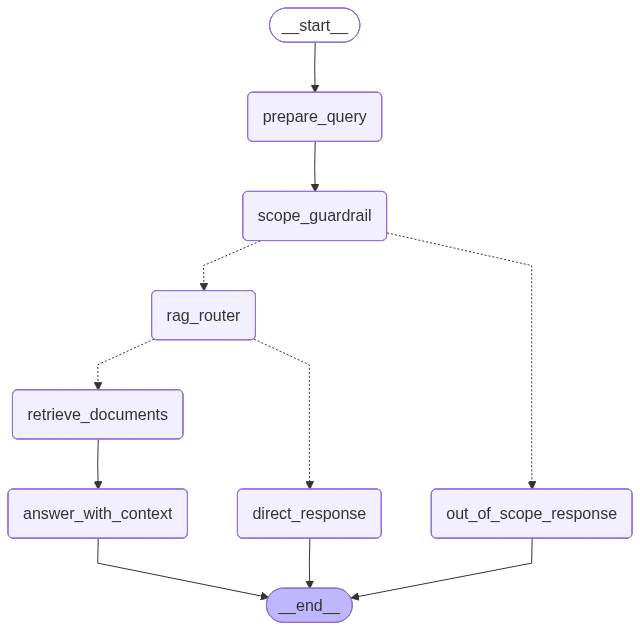

In [56]:
mermaid_code = fiscal_graph.get_graph().draw_mermaid()
print(mermaid_code)

try:
    display(Image(fiscal_graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("No se pudo renderizar el PNG. El código Mermaid anterior sigue siendo válido.")
    print("Detalle:", exc)

## 14. Invocación, memoria, inspección y streaming

In [57]:
def make_thread_config(thread_id: str) -> dict[str, Any]:
    clean_thread_id = str(thread_id).strip()
    if not clean_thread_id:
        raise ValueError("thread_id no puede estar vacío.")

    return {"configurable": {"thread_id": clean_thread_id}}


def ask_agent(
    question: str,
    thread_id: str = "default_thread",
) -> dict[str, Any]:
    clean_question = str(question).strip()
    if not clean_question:
        raise ValueError("La pregunta no puede estar vacía.")

    graph_response = fiscal_graph.invoke(
        {"messages": [HumanMessage(content=clean_question)]},
        config=make_thread_config(thread_id),
    )

    return {
        "question": clean_question,
        "answer": extract_final_answer(graph_response),
        "agent_response": graph_response,
        "thread_id": thread_id,
        "in_scope": graph_response.get("in_scope"),
        "needs_rag": graph_response.get("needs_rag"),
        "tool_used": graph_response.get("tool_used"),
        "retrieval_status": graph_response.get("retrieval_status"),
        "graph_path": graph_response.get("graph_path"),
    }


def inspect_graph_response(result: dict[str, Any]) -> None:
    state = result.get("agent_response", {})

    print("=" * 100)
    print("Pregunta:", result.get("question"))
    print("Thread:", result.get("thread_id"))
    print("In scope:", state.get("in_scope"))
    print("Needs RAG:", state.get("needs_rag"))
    print("Tool usada:", state.get("tool_used"))
    print("Retrieval status:", state.get("retrieval_status"))
    print("Ruta:", state.get("graph_path"))

    if state.get("retrieval_query"):
        print("Retrieval query:", state["retrieval_query"])
    if state.get("retrieved_context"):
        print("Contexto recuperado:", len(state["retrieved_context"]), "caracteres")

    print("=" * 100)
    print("Respuesta:")
    print(result.get("answer", ""))

In [58]:
def stream_agent_updates(
    question: str,
    thread_id: str = "stream_thread",
):
    clean_question = str(question).strip()
    if not clean_question:
        raise ValueError("La pregunta no puede estar vacía.")

    yield from fiscal_graph.stream(
        {"messages": [HumanMessage(content=clean_question)]},
        config=make_thread_config(thread_id),
        stream_mode="updates",
    )


def stream_agent_updates_pretty(
    question: str,
    thread_id: str = "stream_pretty_thread",
) -> None:
    for step_number, step in enumerate(
        stream_agent_updates(question, thread_id),
        start=1,
    ):
        print("=" * 100)
        print(f"STEP {step_number}")

        if step is None or not isinstance(step, dict):
            print(step if step is not None else "[Sin actualización]")
            continue

        for node_name, update in step.items():
            print("NODE:", node_name)

            if update is None:
                print("[Nodo sin actualización]")
                continue

            if node_name == "prepare_query":
                print("Pregunta:", update.get("user_query"))
            elif node_name == "scope_guardrail":
                print("Dentro del ámbito:", update.get("in_scope"))
            elif node_name == "rag_router":
                print("Necesita RAG:", update.get("needs_rag"))
            elif node_name == "retrieve_documents":
                print("Tool ejecutada: search_tax_corpus")
                print(
                    "Contexto recuperado:",
                    len(update.get("retrieved_context", "")),
                    "caracteres",
                )
                print("[Contenido documental oculto]")
            elif node_name in {
                "answer_with_context",
                "direct_response",
                "out_of_scope_response",
            }:
                messages = update.get("messages", [])
                if not isinstance(messages, (list, tuple)):
                    messages = [messages]

                for message in messages:
                    text = message_to_text(message)
                    if text:
                        print("Respuesta:")
                        print(text)
            else:
                safe_update = {
                    key: value
                    for key, value in update.items()
                    if key != "retrieved_context"
                }
                print(safe_update)

### Demos sin Gemini

In [59]:
if RUN_NON_LLM_GRAPH_DEMOS:
    greeting_result = ask_agent("Hola", thread_id="demo_local_greeting")
    inspect_graph_response(greeting_result)

    out_scope_result = ask_agent(
        "Busca una consulta vinculante de la DGT sobre I+D+i.",
        thread_id="demo_local_dgt",
    )
    inspect_graph_response(out_scope_result)
else:
    print("Demos locales desactivadas.")

Pregunta: Hola
Thread: demo_local_greeting
In scope: True
Needs RAG: False
Tool usada: False
Retrieval status: not_run
Ruta: direct_response
Respuesta:
Hola. Puedo ayudarte con Impuesto sobre Sociedades, empresas emergentes y deducciones por I+D+i.
Pregunta: Busca una consulta vinculante de la DGT sobre I+D+i.
Thread: demo_local_dgt
In scope: False
Needs RAG: False
Tool usada: False
Retrieval status: not_run
Ruta: out_of_scope
Respuesta:
No puedo responder con base suficiente usando el corpus cargado.

Pregunta: Busca una consulta vinculante de la DGT sobre I+D+i.

El corpus está limitado a Impuesto sobre Sociedades, empresas emergentes, Ley de Startups y deducciones por I+D+i de los artículos 35 y 39 LIS. Las consultas vinculantes de la DGT todavía no están integradas.


### Demos con Gemini, memoria y separación de hilos

In [61]:
if RUN_GRAPH_LLM_DEMOS:
    fiscal_result = ask_agent(
        "¿Puede una empresa emergente aplicar el tipo reducido del 15%?",
        thread_id="demo_graph_fiscal",
    )
    inspect_graph_response(fiscal_result)

    memory_thread = "demo_graph_memory"
    first_turn = ask_agent(
        "¿Qué requisitos debe cumplir una empresa para ser empresa emergente?",
        thread_id=memory_thread,
    )
    second_turn = ask_agent(
        "¿Y durante cuánto tiempo puede mantener esa condición?",
        thread_id=memory_thread,
    )

    print("\nPRIMER TURNO\n", first_turn["answer"])
    print("\nSEGUNDO TURNO CON MEMORIA\n", second_turn["answer"])

    thread_a = ask_agent(
        "¿Qué se considera innovación tecnológica en el artículo 35.2 LIS?",
        thread_id="thread_innovation",
    )
    thread_b = ask_agent(
        "¿Qué requisitos tiene una empresa emergente?",
        thread_id="thread_startup",
    )

    print("\nHILO A\n", thread_a["answer"])
    print("\nHILO B\n", thread_b["answer"])
else:
    print("Demos con Gemini no ejecutadas porque RUN_GRAPH_LLM_DEMOS=False.")

Pregunta: ¿Puede una empresa emergente aplicar el tipo reducido del 15%?
Thread: demo_graph_fiscal
In scope: True
Needs RAG: True
Tool usada: True
Retrieval status: success
Ruta: rag
Retrieval query: Pregunta actual: ¿Puede una empresa emergente aplicar el tipo reducido del 15%?
Pregunta fiscal anterior del hilo: ¿Puede una empresa emergente aplicar el tipo reducido del 15%?
Términos de recuperación: Requisitos, certificación y pérdida de la condición de empresa emergente conforme a la Ley 28/2022 y la Orden PCM/825/2023.
Contexto recuperado: 6028 caracteres
Respuesta:
1.  **Respuesta.**
    El contexto documental recuperado no contiene información sobre si una empresa emergente puede aplicar el tipo reducido del 15% en el Impuesto sobre Sociedades. El contexto previo sí lo indicaba.

2.  **Base normativa o fuente.**
    Contexto insuficiente.

3.  **Aplicación práctica.**
    Contexto insuficiente.

4.  **Límites o cautelas.**
    Una empresa emergente dejará de acogerse a los benefic

In [62]:
if RUN_GRAPH_STREAM_DEMO:
    stream_agent_updates_pretty(
        "¿Cómo funciona el artículo 39.2 LIS para las deducciones por I+D+i?",
        thread_id="demo_graph_stream",
    )
else:
    print("Streaming con Gemini no ejecutado porque RUN_GRAPH_STREAM_DEMO=False.")

STEP 1
NODE: prepare_query
Pregunta: ¿Cómo funciona el artículo 39.2 LIS para las deducciones por I+D+i?
STEP 2
NODE: scope_guardrail
Dentro del ámbito: True
STEP 3
NODE: rag_router
Necesita RAG: True
STEP 4
NODE: retrieve_documents
Tool ejecutada: search_tax_corpus
Contexto recuperado: 6026 caracteres
[Contenido documental oculto]
STEP 5
NODE: answer_with_context
Respuesta:
1. **Respuesta.**
El artículo 39.2 de la Ley del Impuesto sobre Sociedades (LIS) permite a las entidades que tributan al tipo general optar por excluir las deducciones por actividades de investigación y desarrollo e innovación tecnológica (I+D+i) de los límites conjuntos del 25/50 por ciento establecidos en el artículo 39.1 de la LIS. A cambio, se aplica un descuento del 20 por ciento sobre el importe de estas deducciones. En caso de que la cuota sea insuficiente, se puede solicitar el abono de la deducción a la Administración tributaria, al menos un año después de la finalización del período impositivo en que se g

## 15. Evaluación del workflow con memoria

In [63]:
GRAPH_EVAL_CASES = [
    {
        "id": "graph_tipo_15",
        "question": "¿Puede una empresa emergente aplicar el tipo reducido del 15% en Sociedades?",
        "thread_id": "eval_tipo_15",
        "expected_in_scope": True,
        "expected_needs_rag": True,
        "expected_tool": True,
        "expected_all_terms": ["15"],
        "expected_any_terms": ["empresa emergente", "tipo reducido"],
    },
    {
        "id": "graph_requisitos_emergente",
        "question": "¿Qué requisitos debe cumplir una empresa para ser considerada empresa emergente?",
        "thread_id": "eval_requisitos",
        "expected_in_scope": True,
        "expected_needs_rag": True,
        "expected_tool": True,
        "expected_all_terms": ["empresa emergente"],
        "expected_any_terms": ["requisito", "certificacion", "enisa"],
    },
    {
        "id": "graph_id_articulo_35",
        "question": "¿Qué regula el artículo 35 de la LIS sobre investigación y desarrollo?",
        "thread_id": "eval_articulo_35",
        "expected_in_scope": True,
        "expected_needs_rag": True,
        "expected_tool": True,
        "expected_all_terms": ["35"],
        "expected_any_terms": ["investigacion", "desarrollo", "i+d"],
    },
    {
        "id": "graph_articulo_39_2",
        "question": "¿En qué consiste el régimen del artículo 39.2 LIS para las deducciones por I+D+i?",
        "thread_id": "eval_articulo_39",
        "expected_in_scope": True,
        "expected_needs_rag": True,
        "expected_tool": True,
        "expected_all_terms": ["39.2"],
        "expected_any_terms": ["deduccion", "abono", "limite"],
    },
    {
        "id": "graph_memoria_turno_1",
        "question": "¿Qué requisitos debe cumplir una entidad para ser empresa emergente?",
        "thread_id": "eval_memory",
        "expected_in_scope": True,
        "expected_needs_rag": True,
        "expected_tool": True,
        "expected_all_terms": [],
        "expected_any_terms": ["empresa emergente", "requisito"],
    },
    {
        "id": "graph_memoria_turno_2",
        "question": "¿Y durante cuánto tiempo puede mantener esa condición?",
        "thread_id": "eval_memory",
        "expected_in_scope": True,
        "expected_needs_rag": True,
        "expected_tool": True,
        "expected_all_terms": [],
        "expected_any_terms": ["anos", "periodo", "condicion"],
    },
    {
        "id": "graph_saludo",
        "question": "Hola",
        "thread_id": "eval_greeting",
        "expected_in_scope": True,
        "expected_needs_rag": False,
        "expected_tool": False,
        "expected_all_terms": [],
        "expected_any_terms": ["hola", "puedo ayudarte"],
    },
    {
        "id": "graph_fuera_iva",
        "question": "¿Cómo se presenta el modelo 303 de IVA?",
        "thread_id": "eval_iva",
        "expected_in_scope": False,
        "expected_needs_rag": False,
        "expected_tool": False,
        "expected_all_terms": [],
        "expected_any_terms": ["corpus", "no puedo responder"],
    },
    {
        "id": "graph_fuera_dgt",
        "question": "Busca una consulta vinculante de la DGT sobre I+D+i.",
        "thread_id": "eval_dgt",
        "expected_in_scope": False,
        "expected_needs_rag": False,
        "expected_tool": False,
        "expected_all_terms": [],
        "expected_any_terms": ["dgt", "no estan integradas", "corpus"],
    },
]

In [64]:
def all_terms_present(answer: str, terms: list[str]) -> bool:
    answer_norm = normalize_text(answer)
    return all(normalize_text(term) in answer_norm for term in terms)


def any_term_present(answer: str, terms: list[str]) -> bool:
    if not terms:
        return True
    answer_norm = normalize_text(answer)
    return any(normalize_text(term) in answer_norm for term in terms)


def extract_token_usage(result: dict[str, Any]) -> dict[str, int]:
    state = result.get("agent_response", {})
    totals = {"input_tokens": 0, "output_tokens": 0, "total_tokens": 0, "model_calls": 0}

    for message in state.get("messages", []):
        usage = getattr(message, "usage_metadata", None)
        if not usage:
            continue

        totals["model_calls"] += 1
        totals["input_tokens"] += int(usage.get("input_tokens", 0) or 0)
        totals["output_tokens"] += int(usage.get("output_tokens", 0) or 0)
        totals["total_tokens"] += int(usage.get("total_tokens", 0) or 0)

    return totals


def run_graph_evaluation(cases: list[dict[str, Any]]) -> pd.DataFrame:
    run_suffix = uuid4().hex[:8]
    runtime_threads: dict[str, str] = {}
    rows = []

    for case in cases:
        base_thread = case["thread_id"]
        runtime_threads.setdefault(base_thread, f"{base_thread}_{run_suffix}")
        runtime_thread = runtime_threads[base_thread]

        try:
            result = ask_agent(case["question"], thread_id=runtime_thread)
            answer = result["answer"]

            scope_ok = result["in_scope"] == case["expected_in_scope"]
            rag_ok = result["needs_rag"] == case["expected_needs_rag"]
            tool_ok = result["tool_used"] == case["expected_tool"]
            terms_ok = all_terms_present(answer, case["expected_all_terms"]) and any_term_present(
                answer,
                case["expected_any_terms"],
            )
            answer_ok = bool(answer.strip()) and terms_ok
            overall_ok = scope_ok and rag_ok and tool_ok and answer_ok
            usage = extract_token_usage(result)

            rows.append(
                {
                    "id": case["id"],
                    "question": case["question"],
                    "thread_id": runtime_thread,
                    "expected_in_scope": case["expected_in_scope"],
                    "actual_in_scope": result["in_scope"],
                    "scope_ok": scope_ok,
                    "expected_needs_rag": case["expected_needs_rag"],
                    "actual_needs_rag": result["needs_rag"],
                    "rag_decision_ok": rag_ok,
                    "expected_tool": case["expected_tool"],
                    "tool_used": result["tool_used"],
                    "tool_ok": tool_ok,
                    "retrieval_status": result["retrieval_status"],
                    "graph_path": result["graph_path"],
                    "generation_status": "success",
                    "answer_ok": answer_ok,
                    "overall_ok": overall_ok,
                    **usage,
                    "answer_preview": answer[:1_000],
                    "error_type": None,
                    "error": None,
                }
            )

        except Exception as exc:
            rows.append(
                {
                    "id": case["id"],
                    "question": case["question"],
                    "thread_id": runtime_thread,
                    "expected_in_scope": case["expected_in_scope"],
                    "actual_in_scope": None,
                    "scope_ok": None,
                    "expected_needs_rag": case["expected_needs_rag"],
                    "actual_needs_rag": None,
                    "rag_decision_ok": None,
                    "expected_tool": case["expected_tool"],
                    "tool_used": None,
                    "tool_ok": None,
                    "retrieval_status": None,
                    "graph_path": None,
                    "generation_status": classify_api_error(exc),
                    "answer_ok": None,
                    "overall_ok": None,
                    "input_tokens": None,
                    "output_tokens": None,
                    "total_tokens": None,
                    "model_calls": None,
                    "answer_preview": "",
                    "error_type": type(exc).__name__,
                    "error": str(exc),
                }
            )

    return pd.DataFrame(rows)

In [65]:
if RUN_GRAPH_EVAL:
    graph_eval_df = run_graph_evaluation(GRAPH_EVAL_CASES)
    display(graph_eval_df)

    successful = graph_eval_df[graph_eval_df["generation_status"] == "success"]
    graph_summary_df = pd.DataFrame(
        [
            {
                "cases_total": len(graph_eval_df),
                "cases_success": len(successful),
                "api_errors": int((graph_eval_df["generation_status"] == "api_error").sum()),
                "scope_accuracy": successful["scope_ok"].mean() if not successful.empty else None,
                "rag_router_accuracy": successful["rag_decision_ok"].mean() if not successful.empty else None,
                "tool_accuracy": successful["tool_ok"].mean() if not successful.empty else None,
                "answer_ok_rate": successful["answer_ok"].mean() if not successful.empty else None,
                "overall_ok_rate": successful["overall_ok"].mean() if not successful.empty else None,
                "total_tokens": successful["total_tokens"].sum() if not successful.empty else None,
            }
        ]
    )
    display(graph_summary_df)

    graph_eval_output = EVAL_OUTPUT_DIR / "agent_with_memory_eval.csv"
    graph_eval_df.to_csv(graph_eval_output, index=False, encoding="utf-8-sig")
    print("Guardado en:", graph_eval_output)
else:
    print("Evaluación completa del grafo no ejecutada porque RUN_GRAPH_EVAL=False.")

,id,question,thread_id,expected_in_scope,actual_in_scope,scope_ok,expected_needs_rag,actual_needs_rag,rag_decision_ok,expected_tool,...,generation_status,answer_ok,overall_ok,input_tokens,output_tokens,total_tokens,model_calls,answer_preview,error_type,error
0,graph_tipo_15,¿Puede una empresa emergente aplicar el tipo r...,eval_tipo_15_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,1839,444,2283,1,"1. **Respuesta.**\n Sí, una empresa emerge...",None,None
1,graph_requisitos_emergente,¿Qué requisitos debe cumplir una empresa para ...,eval_requisitos_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,1675,550,2225,1,"Para ser considerada una empresa emergente, un...",None,None
2,graph_id_articulo_35,¿Qué regula el artículo 35 de la LIS sobre inv...,eval_articulo_35_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,1693,534,2227,1,El artículo 35 de la Ley del Impuesto sobre So...,None,None
3,graph_articulo_39_2,¿En qué consiste el régimen del artículo 39.2 ...,eval_articulo_39_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,1794,550,2344,1,1. **Respuesta.**\nEl régimen del artículo 39....,None,None
4,graph_memoria_turno_1,¿Qué requisitos debe cumplir una entidad para ...,eval_memory_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,1674,550,2224,1,Para ser considerada una empresa emergente y a...,None,None
5,graph_memoria_turno_2,¿Y durante cuánto tiempo puede mantener esa co...,eval_memory_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,3591,973,4564,2,1. **Respuesta.**\n Una empresa puede mant...,None,None
6,graph_saludo,Hola,eval_greeting_2ea69f8b,True,True,True,False,False,True,False,...,success,True,True,0,0,0,0,Hola. Puedo ayudarte con Impuesto sobre Socied...,None,None
7,graph_fuera_iva,¿Cómo se presenta el modelo 303 de IVA?,eval_iva_2ea69f8b,False,False,True,False,False,True,False,...,success,True,True,0,0,0,0,No puedo responder con base suficiente usando ...,None,None
8,graph_fuera_dgt,Busca una consulta vinculante de la DGT sobre ...,eval_dgt_2ea69f8b,False,False,True,False,False,True,False,...,success,True,True,0,0,0,0,No puedo responder con base suficiente usando ...,None,None


,cases_total,cases_success,api_errors,scope_accuracy,rag_router_accuracy,tool_accuracy,answer_ok_rate,overall_ok_rate,total_tokens
0,9,9,0,1.0,1.0,1.0,1.0,1.0,15867


Guardado en: C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\GENAI_RAG\data\processed\evaluation\agent_with_memory_eval.csv


## 16. Resultados históricos encontrados en el repositorio

In [66]:
def load_optional_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    return pd.read_csv(path)


historical_retrieval = load_optional_csv(
    PROCESSED_DIR / "retrieval_smoke_test_results.csv"
)
historical_graph = load_optional_csv(
    EVAL_OUTPUT_DIR / "agent_with_memory_eval.csv"
)

if historical_retrieval is not None:
    print("Retrieval histórico:")
    display(historical_retrieval)

if historical_graph is not None:
    print("Evaluación histórica del grafo:")
    display(historical_graph)

    if "overall_ok" in historical_graph.columns:
        print("overall_ok histórico:", historical_graph["overall_ok"].mean())

print(
    "Nota: los CSV antiguos de generación pueden incluir fallos de cuota contados como False. "
    "Los runners de este notebook registran esos casos como api_error y dejan answer_ok=None."
)

Evaluación histórica del grafo:


,id,question,thread_id,expected_in_scope,actual_in_scope,scope_ok,expected_needs_rag,actual_needs_rag,rag_decision_ok,expected_tool,...,generation_status,answer_ok,overall_ok,input_tokens,output_tokens,total_tokens,model_calls,answer_preview,error_type,error
0,graph_tipo_15,¿Puede una empresa emergente aplicar el tipo r...,eval_tipo_15_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,1839,444,2283,1,"1. **Respuesta.**\n Sí, una empresa emerge...",NaN,NaN
1,graph_requisitos_emergente,¿Qué requisitos debe cumplir una empresa para ...,eval_requisitos_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,1675,550,2225,1,"Para ser considerada una empresa emergente, un...",NaN,NaN
2,graph_id_articulo_35,¿Qué regula el artículo 35 de la LIS sobre inv...,eval_articulo_35_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,1693,534,2227,1,El artículo 35 de la Ley del Impuesto sobre So...,NaN,NaN
3,graph_articulo_39_2,¿En qué consiste el régimen del artículo 39.2 ...,eval_articulo_39_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,1794,550,2344,1,1. **Respuesta.**\nEl régimen del artículo 39....,NaN,NaN
4,graph_memoria_turno_1,¿Qué requisitos debe cumplir una entidad para ...,eval_memory_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,1674,550,2224,1,Para ser considerada una empresa emergente y a...,NaN,NaN
5,graph_memoria_turno_2,¿Y durante cuánto tiempo puede mantener esa co...,eval_memory_2ea69f8b,True,True,True,True,True,True,True,...,success,True,True,3591,973,4564,2,1. **Respuesta.**\n Una empresa puede mant...,NaN,NaN
6,graph_saludo,Hola,eval_greeting_2ea69f8b,True,True,True,False,False,True,False,...,success,True,True,0,0,0,0,Hola. Puedo ayudarte con Impuesto sobre Socied...,NaN,NaN
7,graph_fuera_iva,¿Cómo se presenta el modelo 303 de IVA?,eval_iva_2ea69f8b,False,False,True,False,False,True,False,...,success,True,True,0,0,0,0,No puedo responder con base suficiente usando ...,NaN,NaN
8,graph_fuera_dgt,Busca una consulta vinculante de la DGT sobre ...,eval_dgt_2ea69f8b,False,False,True,False,False,True,False,...,success,True,True,0,0,0,0,No puedo responder con base suficiente usando ...,NaN,NaN


overall_ok histórico: 1.0
Nota: los CSV antiguos de generación pueden incluir fallos de cuota contados como False. Los runners de este notebook registran esos casos como api_error y dejan answer_ok=None.


### Chat

In [1]:
from uuid import uuid4


# Cambiar a True cuando se quiera abrir el chat.
RUN_INTERACTIVE_CHAT = False

# Mostrar información técnica del grafo al usuario.
SHOW_GRAPH_STATUS = False


def start_interactive_chat() -> None:
    """
    Inicia una conversación interactiva con el grafo fiscal.

    Comandos:
    - /nuevo  -> inicia una conversación nueva.
    - /hilo   -> muestra el thread_id actual.
    - /ayuda  -> muestra los comandos disponibles.
    - /salir  -> finaliza el chat.
    """

    thread_id = (
        f"interactive_{uuid4().hex[:10]}"
    )

    print("=" * 80)
    print("ASISTENTE FISCAL — GEMINI + RAG + LANGGRAPH")
    print("=" * 80)
    print(
        "Puedes preguntar sobre Impuesto sobre Sociedades, "
        "empresas emergentes y deducciones por I+D+i."
    )
    print()
    print("Comandos disponibles:")
    print("  /nuevo  → iniciar una conversación nueva")
    print("  /hilo   → mostrar el identificador de conversación")
    print("  /ayuda  → mostrar esta ayuda")
    print("  /salir  → cerrar el chat")
    print()
    print("Hilo actual:", thread_id)

    while True:
        try:
            question = input(
                "\nTú: "
            ).strip()

        except (KeyboardInterrupt, EOFError):
            print(
                "\n\nAsistente fiscal: conversación finalizada."
            )
            break

        if not question:
            continue

        normalized_question = normalize_text(
            question
        )

        # --------------------------------------------------
        # Comandos del chat
        # --------------------------------------------------

        if normalized_question in {
            "/salir",
            "salir",
            "exit",
            "quit",
        }:
            print(
                "\nAsistente fiscal: conversación finalizada."
            )
            break

        if normalized_question in {
            "/nuevo",
            "nuevo",
        }:
            thread_id = (
                f"interactive_{uuid4().hex[:10]}"
            )

            print(
                "\nAsistente fiscal: "
                "se ha iniciado una conversación nueva."
            )
            print(
                "Nuevo hilo:",
                thread_id,
            )

            continue

        if normalized_question in {
            "/hilo",
            "hilo",
        }:
            print(
                "\nHilo actual:",
                thread_id,
            )

            continue

        if normalized_question in {
            "/ayuda",
            "ayuda",
        }:
            print("\nComandos disponibles:")
            print("  /nuevo  → nueva conversación")
            print("  /hilo   → mostrar thread_id")
            print("  /salir  → cerrar el chat")

            continue

        # --------------------------------------------------
        # Ejecución del grafo
        # --------------------------------------------------

        try:
            result = ask_agent(
                question=question,
                thread_id=thread_id,
            )

            answer = str(
                result.get(
                    "answer",
                    "",
                )
            ).strip()

            # Fallback por si ask_agent no hubiera
            # extraído la respuesta final.
            if not answer:
                graph_response = result.get(
                    "agent_response",
                    {},
                )

                answer = extract_final_answer(
                    graph_response
                )

            if not answer:
                answer = (
                    "No se ha generado una respuesta."
                )

            print("\nAsistente fiscal:")
            print(answer)

            # Información opcional para depuración o defensa.
            if SHOW_GRAPH_STATUS:
                print("\n--- Estado del grafo ---")
                print(
                    "Dentro de ámbito:",
                    result.get("in_scope"),
                )
                print(
                    "Necesita RAG:",
                    result.get("needs_rag"),
                )
                print(
                    "Estado del retrieval:",
                    result.get("retrieval_status"),
                )
                print(
                    "Thread ID:",
                    thread_id,
                )

        except Exception as exc:
            error_text = normalize_text(
                str(exc)
            )

            api_error_markers = (
                "429",
                "resource_exhausted",
                "quota",
                "rate limit",
                "too many requests",
            )

            is_api_error = any(
                marker in error_text
                for marker in api_error_markers
            )

            if is_api_error:
                print(
                    "\nAsistente fiscal: "
                    "la API de Gemini no está disponible "
                    "en este momento por límite de cuota."
                )

            else:
                print(
                    "\nAsistente fiscal: "
                    "se ha producido un error al procesar "
                    "la consulta."
                )

                print(
                    f"Detalle: {type(exc).__name__}: "
                    f"{str(exc)[:300]}"
                )


if RUN_INTERACTIVE_CHAT:
    start_interactive_chat()

else:
    print(
        "Chat interactivo no iniciado porque "
        "RUN_INTERACTIVE_CHAT = False."
    )
    print(
        "Cambia el flag a True y vuelve a ejecutar "
        "esta celda para comenzar."
    )

Chat interactivo no iniciado porque RUN_INTERACTIVE_CHAT = False.
Cambia el flag a True y vuelve a ejecutar esta celda para comenzar.


## 17. Conclusiones y limitaciones

### Decisiones técnicas

- **Embeddings locales:** evitan consumir cuota de Gemini durante la indexación.
- **Chroma persistente:** permite reutilizar el vectorstore entre sesiones.
- **Tool conservada:** `search_tax_corpus` encapsula el acceso al corpus.
- **LangGraph explícito:** hace visibles los nodos, routers, memoria y rutas de salida.
- **Una sola llamada a Gemini por consulta fiscal:** el guardrail, el router y el retrieval son locales.
- **Contexto limitado:** el corpus no se imprime íntegramente ni se acumula como mensajes del hilo.
- **Errores de API diferenciados:** no se confunden problemas de cuota con fallos funcionales.

### Limitaciones

- El corpus no incorpora consultas vinculantes de la DGT.
- El guardrail y el router son reglas deterministas; deben ampliarse cuando crezca el dominio.
- `InMemorySaver` conserva la memoria mientras el kernel está activo, pero no entre reinicios.
- El asistente aporta información documental y no sustituye asesoramiento fiscal profesional.

In [67]:
print(
    "Notebook preparado.\n"
    f"- Fuentes oficiales: {len(SOURCES)}\n"
    f"- Registros extraídos: {len(extracted_records)}\n"
    f"- Chunks: {len(chunk_records)}\n"
    f"- Vectores en Chroma: {vectorstore_count}\n"
    f"- Tool: {search_tax_corpus.name}\n"
    "- Grafo: prepare_query → scope_guardrail → rag_router → retrieve_documents → answer_with_context\n"
    f"- Gemini habilitado: {GOOGLE_API_KEY_AVAILABLE}\n"
    f"- RUN_GRAPH_EVAL: {RUN_GRAPH_EVAL}"
)

Notebook preparado.
- Fuentes oficiales: 7
- Registros extraídos: 1050
- Chunks: 1688
- Vectores en Chroma: 1688
- Tool: search_tax_corpus
- Grafo: prepare_query → scope_guardrail → rag_router → retrieve_documents → answer_with_context
- Gemini habilitado: True
- RUN_GRAPH_EVAL: True
